<a href="https://colab.research.google.com/github/vn322/Sport-University/blob/main/%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B4%D0%BB%D1%8F_motion_estim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка необходимых библиотек
!pip install openpyxl scipy statsmodels pingouin > /dev/null 2>&1

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest, f_oneway, levene, pearsonr, spearmanr
from scipy.signal import find_peaks, welch
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")
sns.set_style("whitegrid")

# 1. Оценка одного движения

## 1. Загрузка данных

In [2]:
# Загружаем файл
from google.colab import files
print(" Загрузите CSV-файл с биомеханическими данными:")
uploaded = files.upload()

# Получаем имя файла
file_name = list(uploaded.keys())[0]

# Читаем данные
df = pd.read_csv(file_name)

print(f"\n Файл '{file_name}' загружен!")
print(f" Размер данных: {df.shape[0]} кадров, {df.shape[1]} параметров")
print("\n Первые 5 кадров:")
display(df.head())

# Базовая информация
print(f"\n Пропущенные значения: {df.isnull().sum().sum()} ({(df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100):.2f}%)")
print(f"\n Типы данных:")
print(df.dtypes.value_counts())

 Загрузите CSV-файл с биомеханическими данными:


Saving data_1789460532.csv to data_1789460532.csv

 Файл 'data_1789460532.csv' загружен!
 Размер данных: 117 кадров, 38 параметров

 Первые 5 кадров:


,frame_number,avg_visibility,shoulder_left_angle,elbow_left_angle,hip_left_angle,knee_left_angle,shoulder_right_angle,elbow_right_angle,hip_right_angle,knee_right_angle,...,elbow_right_entropy,hip_right_velocity,hip_right_acceleration,hip_right_entropy,knee_right_velocity,knee_right_acceleration,knee_right_entropy,x_factor_velocity,x_factor_acceleration,x_factor_entropy
0,0,0.981,12.170,112.300,155.377,169.583,25.869,80.925,162.433,178.231,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0
1,1,0.980,11.133,112.455,155.433,169.719,25.163,83.545,162.102,177.981,...,0.000,1.245,4.679,0.000,0.942,3.542,0.0,1.445,5.434,0.0
2,2,0.979,10.613,113.264,155.433,169.719,24.882,85.309,162.102,178.062,...,0.000,0.000,9.451,0.000,0.620,2.443,0.0,0.000,10.975,0.0
3,3,0.979,10.595,111.760,155.433,169.719,24.882,87.305,162.102,178.062,...,0.000,0.000,0.000,0.000,0.000,7.358,0.0,0.000,0.000,0.0
4,4,0.978,10.079,112.486,155.433,169.719,24.699,90.000,161.915,178.136,...,0.722,2.000,21.406,0.722,0.789,8.444,0.0,6.862,73.442,0.0



 Пропущенные значения: 0 (0.00%)

 Типы данных:
float64    37
int64       1
Name: count, dtype: int64


## 2. Расширенный статистический анализ

In [3]:
def comprehensive_biomechanical_analysis(df):
    results = {}

    # Разделяем параметры по группам
    angle_cols = [col for col in df.columns if 'angle' in col]
    velocity_cols = [col for col in df.columns if 'velocity' in col]
    acceleration_cols = [col for col in df.columns if 'acceleration' in col]
    entropy_cols = [col for col in df.columns if 'entropy' in col]

    # Левые и правые суставы
    left_joints = ['shoulder_left', 'elbow_left', 'hip_left', 'knee_left']
    right_joints = ['shoulder_right', 'elbow_right', 'hip_right', 'knee_right']

    # 1. Базовые статистики
    results['basic_stats'] = {
        'total_frames': df['frame_number'].nunique(),
        'frame_range': [df['frame_number'].min(), df['frame_number'].max()],
        'avg_visibility_mean': df['avg_visibility'].mean(),
        'avg_visibility_std': df['avg_visibility'].std(),
        'avg_visibility_cv': (df['avg_visibility'].std() / df['avg_visibility'].mean()) * 100
    }

    # 2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЙ
    normality_results = {}
    all_params = angle_cols + velocity_cols + acceleration_cols + entropy_cols

    for param in all_params:
        data = df[param].dropna()
        if len(data) > 3 and len(data) < 5000:  # Shapiro работает лучше для n<5000
            # Тест Шапиро-Уилка
            shapiro_stat, shapiro_p = shapiro(data)
            # Тест Д'Агостино (нормальность)
            dagostino_stat, dagostino_p = normaltest(data)

            # Визуальная оценка
            is_normal_shapiro = shapiro_p > 0.05
            is_normal_dagostino = dagostino_p > 0.05

            normality_results[param] = {
                'shapiro_stat': shapiro_stat,
                'shapiro_p_value': shapiro_p,
                'shapiro_normal': is_normal_shapiro,
                'dagostino_stat': dagostino_stat,
                'dagostino_p_value': dagostino_p,
                'dagostino_normal': is_normal_dagostino,
                'consensus': 'Normal' if (is_normal_shapiro and is_normal_dagostino) else 'Non-normal',
                'skewness': data.skew(),
                'kurtosis': data.kurtosis()
            }
        else:
            normality_results[param] = {
                'error': 'Sample size too large for Shapiro test',
                'skewness': data.skew(),
                'kurtosis': data.kurtosis()
            }

    results['normality_tests'] = normality_results

    # 3. ПОЛНЫЙ КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (все пары)
    correlation_analysis = {}

    # 3.1 Пирсона (для нормальных распределений) и Спирмена (для ненормальных)
    pearson_corrs = []
    spearman_corrs = []

    for i, param1 in enumerate(all_params):
        for param2 in all_params[i+1:]:
            data1 = df[param1].dropna()
            data2 = df[param2].dropna()

            # Объединяем данные по индексам
            common_idx = data1.index.intersection(data2.index)
            if len(common_idx) > 10:
                # Пирсон
                pearson_r, pearson_p = pearsonr(data1[common_idx], data2[common_idx])
                # Спирмен
                spearman_r, spearman_p = spearmanr(data1[common_idx], data2[common_idx])

                pearson_corrs.append({
                    'param1': param1,
                    'param2': param2,
                    'correlation': pearson_r,
                    'p_value': pearson_p,
                    'significant': pearson_p < 0.05,
                    'strength': 'strong' if abs(pearson_r) > 0.7 else 'moderate' if abs(pearson_r) > 0.4 else 'weak'
                })

                spearman_corrs.append({
                    'param1': param1,
                    'param2': param2,
                    'correlation': spearman_r,
                    'p_value': spearman_p,
                    'significant': spearman_p < 0.05
                })

    correlation_analysis['pearson'] = pd.DataFrame(pearson_corrs)
    correlation_analysis['spearman'] = pd.DataFrame(spearman_corrs)

    # 3.2 Корреляции внутри групп
    group_correlations = {}
    for group_name, group_cols in [('angles', angle_cols), ('velocities', velocity_cols),
                                    ('accelerations', acceleration_cols), ('entropies', entropy_cols)]:
        if len(group_cols) > 1:
            group_correlations[group_name] = df[group_cols].corr().to_dict()

    correlation_analysis['within_groups'] = group_correlations

    # 3.3 Кросс-корреляции между разными типами параметров
    cross_correlations = {
        'angle_velocity': [],
        'angle_acceleration': [],
        'velocity_acceleration': []
    }

    for angle in angle_cols:
        for velocity in velocity_cols:
            if angle.split('_')[0] in velocity or velocity.split('_')[0] in angle:
                corr = df[angle].corr(df[velocity])
                if not np.isnan(corr):
                    cross_correlations['angle_velocity'].append({
                        'angle': angle,
                        'velocity': velocity,
                        'correlation': corr,
                        'joint': angle.replace('_angle', '')
                    })

        for acc in acceleration_cols:
            if angle.split('_')[0] in acc or acc.split('_')[0] in angle:
                corr = df[angle].corr(df[acc])
                if not np.isnan(corr):
                    cross_correlations['angle_acceleration'].append({
                        'angle': angle,
                        'acceleration': acc,
                        'correlation': corr
                    })

    for vel in velocity_cols:
        for acc in acceleration_cols:
            if vel.split('_')[0] in acc or acc.split('_')[0] in vel:
                corr = df[vel].corr(df[acc])
                if not np.isnan(corr):
                    cross_correlations['velocity_acceleration'].append({
                        'velocity': vel,
                        'acceleration': acc,
                        'correlation': corr
                    })

    correlation_analysis['cross_correlations'] = cross_correlations

    results['correlations'] = correlation_analysis

    # 4. ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)
    anova_results = {}

    # 4.1 Сравнение левых и правых суставов
    for left_joint, right_joint in zip(left_joints, right_joints):
        left_angle = f'{left_joint}_angle'
        right_angle = f'{right_joint}_angle'

        if left_angle in df.columns and right_angle in df.columns:
            # Подготовка данных для ANOVA
            data_long = pd.DataFrame({
                'angle': pd.concat([df[left_angle], df[right_angle]]),
                'side': ['left']*len(df) + ['right']*len(df)
            }).dropna()

            # Проверка гомогенности дисперсий (Левене)
            levene_stat, levene_p = levene(df[left_angle].dropna(), df[right_angle].dropna())

            # ANOVA
            model = ols('angle ~ C(side)', data=data_long).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)

            # T-тест для дополнительного сравнения
            t_stat, t_p = stats.ttest_ind(df[left_angle].dropna(), df[right_angle].dropna())

            anova_results[f'{left_joint}_vs_{right_joint}'] = {
                'f_statistic': anova_table['F'][0],
                'p_value': anova_table['PR(>F)'][0],
                'significant': anova_table['PR(>F)'][0] < 0.05,
                'levene_stat': levene_stat,
                'levene_p': levene_p,
                'homogeneous_variance': levene_p > 0.05,
                't_statistic': t_stat,
                't_p_value': t_p,
                'effect_size': abs(df[left_angle].mean() - df[right_angle].mean()) / np.sqrt((df[left_angle].std()**2 + df[right_angle].std()**2)/2)  # Cohen's d
            }

    # 4.2 Сравнение различных фаз движения (разбиваем на 3 фазы)
    n_frames = len(df)
    phase_size = n_frames // 3

    phase_labels = ['Начальная', 'Средняя', 'Финальная']
    df['phase'] = pd.cut(df.index, bins=3, labels=phase_labels)

    # ANOVA для каждого параметра по фазам движения
    phase_anova = {}
    for param in all_params[:20]:  # Ограничим для первых 20 параметров
        data_by_phase = [df[df['phase'] == phase][param].dropna().values for phase in phase_labels]
        valid_phases = [data for data in data_by_phase if len(data) > 0]

        if len(valid_phases) >= 2:
            f_stat, p_val = f_oneway(*valid_phases)

            phase_anova[param] = {
                'f_statistic': f_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'phase_means': {phase: df[df['phase'] == phase][param].mean() for phase in phase_labels}
            }

    anova_results['phase_analysis'] = phase_anova

    # 4.3 Влияние видимости на точность измерений
    visibility_groups = pd.cut(df['avg_visibility'], bins=3, labels=['Низкая', 'Средняя', 'Высокая'])
    visibility_anova = {}

    for param in angle_cols[:10]:
        data_by_visibility = [df[visibility_groups == group][param].dropna().values for group in ['Низкая', 'Средняя', 'Высокая']]
        valid_groups = [data for data in data_by_visibility if len(data) > 0]

        if len(valid_groups) >= 2:
            f_stat, p_val = f_oneway(*valid_groups)
            visibility_anova[param] = {
                'f_statistic': f_stat,
                'p_value': p_val,
                'significant': p_val < 0.05
            }

    anova_results['visibility_impact'] = visibility_anova

    results['anova'] = anova_results

    # 5. ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИЧЕСКИЕ МЕТОДЫ

    # 5.1 Факторный анализ (PCA для уменьшения размерности)
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # Подготовка данных для PCA
    pca_data = df[all_params].dropna()
    if len(pca_data) > len(all_params):
        scaler = StandardScaler()
        pca_data_scaled = scaler.fit_transform(pca_data)

        pca = PCA()
        pca_result = pca.fit(pca_data_scaled)

        # Объясненная дисперсия
        explained_variance = pca_result.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)

        # Главные компоненты
        components_df = pd.DataFrame(
            pca_result.components_[:5],
            columns=all_params,
            index=[f'PC{i+1}' for i in range(5)]
        )

        results['pca'] = {
            'explained_variance_ratio': explained_variance.tolist(),
            'cumulative_variance': cumulative_variance.tolist(),
            'n_components_for_80%': np.argmax(cumulative_variance >= 0.8) + 1,
            'n_components_for_95%': np.argmax(cumulative_variance >= 0.95) + 1,
            'components': components_df.to_dict(),
            'loading_scores': {param: pca_result.components_[0][i] for i, param in enumerate(all_params)}
        }

    # 5.2 Анализ временных рядов (автокорреляция)
    autocorrelation_results = {}
    for param in all_params[:15]:  # Первые 15 параметров
        data = df[param].dropna()
        if len(data) > 10:
            # Автокорреляция с лагом 1
            autocorr_lag1 = data.autocorr(lag=1)
            autocorr_lag5 = data.autocorr(lag=min(5, len(data)//4))
            autocorr_lag10 = data.autocorr(lag=min(10, len(data)//4))

            autocorrelation_results[param] = {
                'lag1': autocorr_lag1,
                'lag5': autocorr_lag5,
                'lag10': autocorr_lag10,
                'interpretation': 'Strong temporal dependence' if abs(autocorr_lag1) > 0.7
                                 else 'Moderate dependence' if abs(autocorr_lag1) > 0.4
                                 else 'Weak or no dependence'
            }

    results['autocorrelation'] = autocorrelation_results

    # 5.3 Анализ выбросов множеством методов
    outlier_analysis = {}
    for param in all_params:
        data = df[param].dropna()
        if len(data) > 0:
            # Метод IQR
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            iqr_outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()

            # Метод Z-счета
            z_scores = np.abs(stats.zscore(data))
            z_outliers = (z_scores > 3).sum()

            # Метод MAD (Median Absolute Deviation)
            median = data.median()
            mad = np.median(np.abs(data - median))
            modified_z_scores = 0.6745 * (data - median) / mad if mad > 0 else np.zeros_like(data)
            mad_outliers = (np.abs(modified_z_scores) > 3.5).sum()

            outlier_analysis[param] = {
                'total_outliers_iqr': int(iqr_outliers),
                'pct_outliers_iqr': (iqr_outliers / len(data)) * 100,
                'total_outliers_zscore': int(z_outliers),
                'pct_outliers_zscore': (z_outliers / len(data)) * 100,
                'total_outliers_mad': int(mad_outliers),
                'pct_outliers_mad': (mad_outliers / len(data)) * 100,
                'consensus_outliers': iqr_outliers > 0 and z_outliers > 0 and mad_outliers > 0
            }

    results['outlier_analysis'] = outlier_analysis

    # 5.4 Асимметрия и эксцесс для всех параметров
    distribution_moments = {}
    for param in all_params:
        data = df[param].dropna()
        if len(data) > 0:
            skewness = data.skew()
            kurtosis = data.kurtosis()

            # Интерпретация
            if abs(skewness) < 0.5:
                skew_type = 'approximately symmetric'
            elif skewness > 0:
                skew_type = 'right-skewed (positive skew)'
            else:
                skew_type = 'left-skewed (negative skew)'

            if kurtosis > 0:
                kurt_type = 'leptokurtic (heavy tails, peaked)'
            elif kurtosis < 0:
                kurt_type = 'platykurtic (light tails, flat)'
            else:
                kurt_type = 'mesokurtic (normal-like)'

            distribution_moments[param] = {
                'skewness': skewness,
                'skewness_type': skew_type,
                'kurtosis': kurtosis,
                'kurtosis_type': kurt_type,
                'range': data.max() - data.min(),
                'cv': (data.std() / data.mean()) * 100 if data.mean() != 0 else np.inf
            }

    results['distribution_moments'] = distribution_moments

    return results, angle_cols, velocity_cols, acceleration_cols, entropy_cols, left_joints, right_joints, all_params

## 3. Генерация расширенного аналитического отчёта

In [4]:
def generate_comprehensive_report(df, results, all_params):
    report = []
    report.append("="*100)
    report.append("РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ БИОМЕХАНИЧЕСКИХ ДАННЫХ")
    report.append("="*100)
    report.append(f"\n Дата анализа: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
    report.append(f" Объём выборки: {results['basic_stats']['total_frames']} кадров")
    report.append(f" Количество параметров: {len(all_params)}")

    # 1. НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЙ
    report.append("\n" + "="*100)
    report.append("1. АНАЛИЗ НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЙ")
    report.append("-"*100)

    normal_count = 0
    non_normal_count = 0

    for param, norm_res in results['normality_tests'].items():
        if 'consensus' in norm_res:
            if norm_res['consensus'] == 'Normal':
                normal_count += 1
            else:
                non_normal_count += 1

    report.append(f"\n Распределение типов данных:")
    report.append(f"   • Нормальное распределение: {normal_count} параметров ({normal_count/len(results['normality_tests'])*100:.1f}%)")
    report.append(f"   • Ненормальное распределение: {non_normal_count} параметров ({non_normal_count/len(results['normality_tests'])*100:.1f}%)")

    report.append("\n ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ПО КЛЮЧЕВЫМ ПАРАМЕТРАМ:")

    # Показываем результаты для углов
    for param in [p for p in results['normality_tests'].keys() if 'angle' in p][:8]:
        if 'consensus' in results['normality_tests'][param]:
            norm_res = results['normality_tests'][param]
            report.append(f"\n• {param}:")
            report.append(f"  - Тест Шапиро-Уилка: p={norm_res['shapiro_p_value']:.4f} {'(нормальное)' if norm_res['shapiro_normal'] else '(НЕ нормальное)'}")
            report.append(f"  - Асимметрия: {norm_res['skewness']:.3f}")
            report.append(f"  - Эксцесс: {norm_res['kurtosis']:.3f}")

            if abs(norm_res['skewness']) > 1:
                report.append(f"  → Выраженная асимметрия распределения")
            elif abs(norm_res['skewness']) > 0.5:
                report.append(f"  → Умеренная асимметрия")

    # 2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
    report.append("\n" + "="*100)
    report.append("2. ПОЛНЫЙ КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
    report.append("-"*100)

    # 2.1 Сильные корреляции Пирсона
    strong_pearson = results['correlations']['pearson'][results['correlations']['pearson']['strength'] == 'strong']

    report.append(f"\n СИЛЬНЫЕ КОРРЕЛЯЦИИ (|r| > 0.7): обнаружено {len(strong_pearson)} пар")

    if len(strong_pearson) > 0:
        report.append("\nТоп-10 наиболее сильных корреляций:")
        top_corrs = strong_pearson.nlargest(10, 'correlation')
        for _, row in top_corrs.iterrows():
            report.append(f"   • {row['param1']} ↔ {row['param2']}: r = {row['correlation']:.3f} (p={row['p_value']:.4f})")

    # 2.2 Кросс-корреляции
    report.append("\n КРОСС-КОРРЕЛЯЦИИ МЕЖДУ РАЗНЫМИ ТИПАМИ ПАРАМЕТРОВ:")

    angle_vel_corr = [c for c in results['correlations']['cross_correlations']['angle_velocity'] if abs(c['correlation']) > 0.5]
    if angle_vel_corr:
        report.append(f"   • Угол ↔ Скорость: {len(angle_vel_corr)} сильных связей (средняя r = {np.mean([abs(c['correlation']) for c in angle_vel_corr]):.3f})")
    else:
        report.append(f"   • Угол ↔ Скорость: сильных связей не обнаружено")

    angle_acc_corr = [c for c in results['correlations']['cross_correlations']['angle_acceleration'] if abs(c['correlation']) > 0.5]
    if angle_acc_corr:
        report.append(f"   • Угол ↔ Ускорение: {len(angle_acc_corr)} сильных связей")
    else:
        report.append(f"   • Угол ↔ Ускорение: сильных связей не обнаружено")

    vel_acc_corr = [c for c in results['correlations']['cross_correlations']['velocity_acceleration'] if abs(c['correlation']) > 0.5]
    if vel_acc_corr:
        report.append(f"   • Скорость ↔ Ускорение: {len(vel_acc_corr)} сильных связей")
    else:
        report.append(f"   • Скорость ↔ Ускорение: сильных связей не обнаружено")

    # 3. ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)
    report.append("\n" + "="*100)
    report.append("3. ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)")
    report.append("-"*100)

    # 3.1 Сравнение левых и правых суставов
    report.append("\n СРАВНЕНИЕ ЛЕВОЙ И ПРАВОЙ СТОРОН:")

    significant_diffs = 0
    for test_name, anova_res in results['anova'].items():
        if test_name != 'phase_analysis' and test_name != 'visibility_impact':
            if anova_res['significant']:
                significant_diffs += 1
                report.append(f"\n• {test_name.replace('_vs_', ' ↔ ').replace('_', ' ').title()}:")
                report.append(f"  - F-статистика: {anova_res['f_statistic']:.3f}")
                report.append(f"  - p-value: {anova_res['p_value']:.4f} {'(ЗНАЧИМО)' if anova_res['p_value'] < 0.05 else '(не значимо)'}")
                report.append(f"  - Cohen's d (размер эффекта): {anova_res['effect_size']:.3f}")

                if anova_res['effect_size'] > 0.8:
                    report.append(f"  → БОЛЬШОЙ ЭФФЕКТ (различие очень значительно)")
                elif anova_res['effect_size'] > 0.5:
                    report.append(f"  → Средний эффект")
                else:
                    report.append(f"  → Малый эффект")

    total_tests = len([k for k in results['anova'].keys() if k not in ['phase_analysis', 'visibility_impact']])
    report.append(f"\n Статистически значимых различий между сторонами: {significant_diffs} из {total_tests}")

    # 3.2 Фазовый анализ
    report.append("\n АНАЛИЗ ПО ФАЗАМ ДВИЖЕНИЯ:")
    phase_sig_count = sum(1 for res in results['anova']['phase_analysis'].values() if res['significant'])
    report.append(f"   • Параметров с значимыми изменениями по фазам: {phase_sig_count} из {len(results['anova']['phase_analysis'])}")

    if phase_sig_count > 0:
        report.append("\n   Параметры с наиболее выраженными фазовыми изменениями:")
        phase_diffs = []
        for param, res in results['anova']['phase_analysis'].items():
            if res['significant']:
                phase_range = max(res['phase_means'].values()) - min(res['phase_means'].values())
                phase_diffs.append((param, phase_range, res['f_statistic']))

        phase_diffs.sort(key=lambda x: x[1], reverse=True)
        for param, diff, f_stat in phase_diffs[:5]:
            report.append(f"   • {param}: размах = {diff:.2f}, F = {f_stat:.2f}")

    # 4. ФАКТОРНЫЙ АНАЛИЗ (PCA)
    if 'pca' in results:
        report.append("\n" + "="*100)
        report.append("4. ФАКТОРНЫЙ АНАЛИЗ (PCA - МЕТОД ГЛАВНЫХ КОМПОНЕНТ)")
        report.append("-"*100)

        pca_res = results['pca']
        report.append(f"\n Объяснённая дисперсия:")
        report.append(f"   • PC1: {pca_res['explained_variance_ratio'][0]*100:.1f}% дисперсии")
        report.append(f"   • PC2: {pca_res['explained_variance_ratio'][1]*100:.1f}%")
        report.append(f"   • PC3: {pca_res['explained_variance_ratio'][2]*100:.1f}%")
        report.append(f"\n   • Для объяснения 80% дисперсии требуется {pca_res['n_components_for_80%']} компонент")
        report.append(f"   • Для объяснения 95% дисперсии требуется {pca_res['n_components_for_95%']} компонент")

        report.append(f"\n Наиболее важные переменные в первой главной компоненте:")
        loadings = sorted(pca_res['loading_scores'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
        for param, loading in loadings:
            report.append(f"   • {param}: {loading:.3f}")

    # 5. АНАЛИЗ ВРЕМЕННЫХ РЯДОВ
    report.append("\n" + "="*100)
    report.append("5. АНАЛИЗ ВРЕМЕННЫХ РЯДОВ (АВТОКОРРЕЛЯЦИЯ)")
    report.append("-"*100)

    autocorr_results = results['autocorrelation']
    strong_autocorr = sum(1 for res in autocorr_results.values() if abs(res['lag1']) > 0.7)

    report.append(f"\n Временная зависимость в данных:")
    report.append(f"   • Параметров с сильной автокорреляцией (lag1): {strong_autocorr} из {len(autocorr_results)}")
    report.append(f"   • Параметров с умеренной автокорреляцией: {sum(1 for res in autocorr_results.values() if 0.4 < abs(res['lag1']) <= 0.7)}")

    if strong_autocorr > 0:
        report.append(f"\n   Параметры с наибольшей временной зависимостью:")
        high_autocorr = sorted(autocorr_results.items(), key=lambda x: abs(x[1]['lag1']), reverse=True)[:3]
        for param, res in high_autocorr:
            report.append(f"   • {param}: lag1 = {res['lag1']:.3f}, lag5 = {res['lag5']:.3f}")

    # 6. АНАЛИЗ РАСПРЕДЕЛЕНИЙ (АСИММЕТРИЯ И ЭКСЦЕСС)
    report.append("\n" + "="*100)
    report.append("6. ДЕТАЛЬНЫЙ АНАЛИЗ ФОРМЫ РАСПРЕДЕЛЕНИЙ")
    report.append("-"*100)

    dist_moments = results['distribution_moments']

    # Асимметрия
    skewed_right = [p for p, d in dist_moments.items() if d['skewness'] > 0.5]
    skewed_left = [p for p, d in dist_moments.items() if d['skewness'] < -0.5]

    report.append(f"\n Асимметрия распределений:")
    report.append(f"   • Правосторонняя асимметрия (скошены вправо): {len(skewed_right)} параметров")
    report.append(f"   • Левосторонняя асимметрия (скошены влево): {len(skewed_left)} параметров")
    report.append(f"   • Симметричные распределения: {len(dist_moments) - len(skewed_right) - len(skewed_left)} параметров")

    # Эксцесс
    leptokurtic = [p for p, d in dist_moments.items() if d['kurtosis'] > 0]
    platykurtic = [p for p, d in dist_moments.items() if d['kurtosis'] < 0]

    report.append(f"\n Эксцесс (острота пика):")
    report.append(f"   • Лептокуртические (острые пики, тяжёлые хвосты): {len(leptokurtic)} параметров")
    report.append(f"   • Платикуртические (плоские вершины): {len(platykurtic)} параметров")
    report.append(f"   • Мезокуртические (нормальные): {len(dist_moments) - len(leptokurtic) - len(platykurtic)} параметров")

    # Примеры
    if len(skewed_right) > 0:
        report.append(f"\n   Примеры параметров с сильной асимметрией:")
        high_skew = sorted([(p, d['skewness']) for p, d in dist_moments.items() if abs(d['skewness']) > 1],
                          key=lambda x: abs(x[1]), reverse=True)[:3]
        for param, skew in high_skew:
            report.append(f"   • {param}: skewness = {skew:.3f}")

    # 7. АНАЛИЗ ВЫБРОСОВ
    report.append("\n" + "="*100)
    report.append("7. МНОГОМЕРНЫЙ АНАЛИЗ ВЫБРОСОВ")
    report.append("-"*100)

    outlier_res = results['outlier_analysis']

    high_outlier_params = [p for p, d in outlier_res.items() if d['pct_outliers_iqr'] > 5]
    moderate_outlier_params = [p for p, d in outlier_res.items() if 1 < d['pct_outliers_iqr'] <= 5]

    report.append(f"\n Количество выбросов по разным методам:")
    report.append(f"   • Метод IQR: средний процент выбросов = {np.mean([d['pct_outliers_iqr'] for d in outlier_res.values()]):.1f}%")
    report.append(f"   • Метод Z-счета: средний процент = {np.mean([d['pct_outliers_zscore'] for d in outlier_res.values()]):.1f}%")
    report.append(f"   • Метод MAD: средний процент = {np.mean([d['pct_outliers_mad'] for d in outlier_res.values()]):.1f}%")

    report.append(f"\n Параметров с высоким содержанием выбросов (>5% по IQR): {len(high_outlier_params)}")
    if len(high_outlier_params) > 0:
        report.append(f"\n   Параметры с наибольшим количеством выбросов:")
        high_outliers = sorted([(p, d['pct_outliers_iqr']) for p, d in outlier_res.items()],
                              key=lambda x: x[1], reverse=True)[:5]
        for param, pct in high_outliers:
            report.append(f"   • {param}: {pct:.1f}% выбросов")

    # 8. КОЭФФИЦИЕНТЫ ВАРИАЦИИ
    report.append("\n" + "="*100)
    report.append("8. ИЗМЕНЧИВОСТЬ ПАРАМЕТРОВ (КОЭФФИЦИЕНТ ВАРИАЦИИ)")
    report.append("-"*100)

    # Исправленная часть - удалена неопределённая переменная dist_motors
    cv_values = [d['cv'] for d in dist_moments.values() if d['cv'] != np.inf]

    if len(cv_values) > 0:
        report.append(f"\n Общая изменчивость данных:")
        report.append(f"   • Средний коэффициент вариации: {np.mean(cv_values):.1f}%")
        report.append(f"   • Медианный CV: {np.median(cv_values):.1f}%")
        report.append(f"   • Диапазон CV: {np.min(cv_values):.1f}% - {np.max(cv_values):.1f}%")

    # Наиболее и наименее вариабельные параметры
    sorted_by_cv = sorted([(p, d['cv']) for p, d in dist_moments.items() if d['cv'] != np.inf],
                         key=lambda x: x[1], reverse=True)

    if len(sorted_by_cv) > 0:
        report.append(f"\n Наиболее вариабельные параметры (высокая изменчивость):")
        for param, cv in sorted_by_cv[:3]:
            report.append(f"   • {param}: CV = {cv:.1f}%")

        report.append(f"\n Наименее вариабельные параметры (стабильные):")
        for param, cv in sorted_by_cv[-3:]:
            report.append(f"   • {param}: CV = {cv:.1f}%")

    # 9. СТАТИСТИЧЕСКИЕ ВЫВОДЫ
    report.append("\n" + "="*100)
    report.append("9. СТАТИСТИЧЕСКИЕ ВЫВОДЫ")
    report.append("-"*100)

    # Основные выводы на основе анализа
    report.append("\n ХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЙ:")
    if normal_count > non_normal_count:
        report.append(f"   • Большинство параметров ({normal_count}/{len(results['normality_tests'])}) имеют нормальное распределение")
        report.append(f"   → Можно применять параметрические тесты (Пирсон, t-тест, ANOVA)")
    else:
        report.append(f"   • Большинство параметров ({non_normal_count}/{len(results['normality_tests'])}) имеют НЕнормальное распределение")
        report.append(f"   → Рекомендуется использовать непараметрические методы (Спирмен, U-Манна-Уитни)")

    report.append("\n КОРРЕЛЯЦИОННЫЕ СВЯЗИ:")
    if len(strong_pearson) > 20:
        report.append(f"   • Обнаружено множество сильных корреляций ({len(strong_pearson)} пар)")
        report.append(f"   → Высокая степень взаимосвязи между параметрами, возможна избыточность данных")
    elif len(strong_pearson) > 5:
        report.append(f"   • Обнаружено {len(strong_pearson)} сильных корреляций")
        report.append(f"   → Умеренная взаимосвязь параметров")
    else:
        report.append(f"   • Сильных корреляций мало ({len(strong_pearson)})")
        report.append(f"   → Параметры относительно независимы")

    report.append("\n ВРЕМЕННАЯ СТРУКТУРА:")
    if strong_autocorr > len(autocorr_results) * 0.7:
        report.append(f"   • Очень сильная временная зависимость ({strong_autocorr}/{len(autocorr_results)} параметров)")
        report.append(f"   → Данные имеют ярко выраженную трендовую или циклическую структуру")
    elif strong_autocorr > len(autocorr_results) * 0.3:
        report.append(f"   • Умеренная временная зависимость")
    else:
        report.append(f"   • Слабая временная зависимость")

    report.append("\n ИЗМЕНЧИВОСТЬ:")
    if len(cv_values) > 0:
        if np.mean(cv_values) > 30:
            report.append(f"   • Очень высокая изменчивость параметров (средний CV = {np.mean(cv_values):.1f}%)")
            report.append(f"   → Движения сильно вариабельны")
        elif np.mean(cv_values) > 15:
            report.append(f"   • Умеренная изменчивость параметров (средний CV = {np.mean(cv_values):.1f}%)")
        else:
            report.append(f"   • Низкая изменчивость (средний CV = {np.mean(cv_values):.1f}%), стабильные движения")

    # 10. МЕТОДОЛОГИЧЕСКИЕ РЕКОМЕНДАЦИИ
    report.append("\n" + "="*100)
    report.append("10. МЕТОДОЛОГИЧЕСКИЕ РЕКОМЕНДАЦИИ")
    report.append("-"*100)

    report.append("\n Для углублённого анализа рекомендуется:")

    # На основе PCA
    if 'pca' in results:
        if results['pca']['n_components_for_80%'] < len(all_params) * 0.3:
            report.append(f"   • Учитывая PCA, можно сократить размерность с {len(all_params)} до {results['pca']['n_components_for_80%']} компонент")
            report.append(f"   → Это позволит упростить модель, сохранив 80% информации")

    # На основе корреляций
    if len(strong_pearson) > 10:
        report.append(f"   • Из-за высокой мультиколлинеарности, при регрессионном анализе используйте")
        report.append(f"     регуляризацию (Ridge, Lasso) или методы понижения размерности")

    # На основе временной структуры
    if strong_autocorr > len(autocorr_results) * 0.5:
        report.append(f"   • Для прогнозирования используйте методы временных рядов (ARIMA, LSTM)")
        report.append(f"     или учитывайте лаговые переменные")

    # На основе нормальности
    if non_normal_count > normal_count:
        report.append(f"   • Для статистических тестов предпочтительнее непараметрические методы")
        report.append(f"     (Spearman вместо Pearson, Mann-Whitney вместо t-test)")

    # На основе выбросов
    if len(high_outlier_params) > len(all_params) * 0.3:
        report.append(f"   • Много выбросов ({len(high_outlier_params)} параметров) - рассмотрите робастные методы")
        report.append(f"     или предварительную фильтрацию данных")

    report.append("\n" + "="*100)
    report.append("КОНЕЦ СТАТИСТИЧЕСКОГО ОТЧЁТА")
    report.append("="*100)

    return "\n".join(report)

## 4. Расширенная визуализация распределений

In [5]:
def create_advanced_visualizations(df, results, all_params):
    fig_paths = []

    # 1. Гистограммы с кривыми нормального распределения для проверки нормальности
    n_params = min(9, len([p for p in all_params if 'angle' in p or 'velocity' in p]))
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    params_to_plot = [p for p in all_params if 'angle' in p or 'velocity' in p][:n_params]

    for idx, param in enumerate(params_to_plot):
        data = df[param].dropna()
        axes[idx].hist(data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

        # Добавляем кривую нормального распределения
        mu, std = data.mean(), data.std()
        xmin, xmax = axes[idx].get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, mu, std)
        axes[idx].plot(x, p, 'k', linewidth=2, label='Нормальное распределение')

        axes[idx].set_title(f'{param}\nskew={data.skew():.2f}, kurt={data.kurtosis():.2f}')
        axes[idx].legend()

    # Скрываем лишние подграфики
    for idx in range(len(params_to_plot), 9):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('distributions_with_normal.png', dpi=150, bbox_inches='tight')
    fig_paths.append('distributions_with_normal.png')
    plt.show()

    # 2. Q-Q plots для оценки нормальности
    n_params = min(9, len([p for p in all_params if 'angle' in p or 'acceleration' in p]))
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    params_to_plot = [p for p in all_params if 'angle' in p or 'acceleration' in p][:n_params]

    for idx, param in enumerate(params_to_plot):
        data = df[param].dropna()
        sm.qqplot(data, line='s', ax=axes[idx])
        axes[idx].set_title(f'Q-Q plot: {param}')

    for idx in range(len(params_to_plot), 9):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
    fig_paths.append('qq_plots.png')
    plt.show()

    # 3. Тепловая карта корреляций для всех параметров
    if len(all_params) > 1:
        plt.figure(figsize=(20, 18))
        corr_matrix = df[all_params].corr()
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
                    center=0, square=True, linewidths=0.1,
                    cbar_kws={"shrink": 0.8})
        plt.title('Полная корреляционная матрица всех параметров', fontsize=16)
        plt.xticks(rotation=90, ha='right', fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.savefig('full_correlation_matrix.png', dpi=150, bbox_inches='tight')
        fig_paths.append('full_correlation_matrix.png')
        plt.show()

    # 4. Violin plots для сравнения распределений
    if len(all_params) > 3:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        # Сравнение левых и правых суставов
        comparisons = [
            ('shoulder_left_angle', 'shoulder_right_angle', 'Плечевой сустав'),
            ('elbow_left_angle', 'elbow_right_angle', 'Локтевой сустав'),
            ('hip_left_angle', 'hip_right_angle', 'Тазобедренный сустав'),
            ('knee_left_angle', 'knee_right_angle', 'Коленный сустав')
        ]

        for idx, (left_col, right_col, title) in enumerate(comparisons):
            if idx < 4 and left_col in df.columns and right_col in df.columns:
                data_to_plot = [df[left_col].dropna(), df[right_col].dropna()]
                positions = [1, 2]

                parts = axes[idx].violinplot(data_to_plot, positions, showmeans=True, showmedians=True)
                axes[idx].set_xticks(positions)
                axes[idx].set_xticklabels(['Левый', 'Правый'])
                axes[idx].set_ylabel('Угол (градусы)')
                axes[idx].set_title(f'Сравнение распределений: {title}')
                axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('violin_comparisons.png', dpi=150, bbox_inches='tight')
        fig_paths.append('violin_comparisons.png')
        plt.show()

    # 5. График главных компонент (PCA)
    if 'pca' in results:
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler

        # Подготовка данных
        pca_data = df[all_params].dropna()
        if len(pca_data) > len(all_params):
            scaler = StandardScaler()
            pca_data_scaled = scaler.fit_transform(pca_data)

            pca = PCA(n_components=2)
            pca_result = pca.fit_transform(pca_data_scaled)

            plt.figure(figsize=(12, 8))
            scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df.loc[pca_data.index, 'avg_visibility'],
                                 cmap='viridis', alpha=0.6, s=10)
            plt.colorbar(scatter, label='Средняя видимость')
            plt.xlabel(f'PC1 ({results["pca"]["explained_variance_ratio"][0]*100:.1f}%)')
            plt.ylabel(f'PC2 ({results["pca"]["explained_variance_ratio"][1]*100:.1f}%)')
            plt.title('PCA: Проекция данных на первые две главные компоненты')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('pca_projection.png', dpi=150, bbox_inches='tight')
            fig_paths.append('pca_projection.png')
            plt.show()

    # 6. Boxplot всех углов для выявления выбросов (ИСПРАВЛЕНА ОШИБКА С rot)
    angle_cols = [col for col in all_params if 'angle' in col]
    if len(angle_cols) > 0:
        plt.figure(figsize=(16, 8))
        data_to_box = [df[col].dropna() for col in angle_cols]

        # Создаём boxplot без параметра rot
        bp = plt.boxplot(data_to_box, patch_artist=True)

        # Настраиваем подписи осей
        labels = [col.replace('_angle', '') for col in angle_cols]
        plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')

        # Раскрашиваем boxplots
        for box in bp['boxes']:
            box.set_alpha(0.7)

        plt.ylabel('Угол (градусы)')
        plt.title('Распределение углов и выбросы по всем суставам')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig('angles_boxplot_all.png', dpi=150, bbox_inches='tight')
        fig_paths.append('angles_boxplot_all.png')
        plt.show()

    # 7. Дополнительный график: тепловая карта выбросов по параметрам
    if 'outlier_analysis' in results:
        outlier_res = results['outlier_analysis']
        outlier_pcts = {param: data['pct_outliers_iqr'] for param, data in outlier_res.items()}

        if len(outlier_pcts) > 0:
            plt.figure(figsize=(14, 8))
            params_list = list(outlier_pcts.keys())
            pcts_list = list(outlier_pcts.values())

            # Сортируем по убыванию
            sorted_indices = np.argsort(pcts_list)[::-1]
            params_sorted = [params_list[i] for i in sorted_indices[:20]]  # топ-20
            pcts_sorted = [pcts_list[i] for i in sorted_indices[:20]]

            colors = ['red' if p > 5 else 'orange' if p > 1 else 'green' for p in pcts_sorted]
            plt.barh(range(len(params_sorted)), pcts_sorted, color=colors)
            plt.yticks(range(len(params_sorted)), params_sorted)
            plt.xlabel('Процент выбросов (%)')
            plt.title('Анализ выбросов по параметрам (метод IQR)')
            plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Критический уровень (5%)')
            plt.axvline(x=1, color='orange', linestyle='--', alpha=0.5, label='Умеренный уровень (1%)')
            plt.legend()
            plt.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.savefig('outliers_analysis.png', dpi=150, bbox_inches='tight')
            fig_paths.append('outliers_analysis.png')
            plt.show()

    # 8. График автокорреляций для выбранных параметров
    if 'autocorrelation' in results and len(results['autocorrelation']) > 0:
        autocorr_res = results['autocorrelation']

        # Выбираем 3 параметра с самой сильной и самой слабой автокорреляцией
        autocorr_items = list(autocorr_res.items())
        autocorr_items.sort(key=lambda x: abs(x[1]['lag1']), reverse=True)

        top_autocorr = autocorr_items[:3]
        bottom_autocorr = autocorr_items[-3:]

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for idx, (param, acf_res) in enumerate(top_autocorr + bottom_autocorr):
            if idx < 6:
                data = df[param].dropna()
                if len(data) > 10:
                    # Вычисляем автокорреляционную функцию
                    lags = range(min(20, len(data)//4))
                    acf_values = [data.autocorr(lag=lag) for lag in lags]

                    axes[idx].bar(lags, acf_values, alpha=0.7)
                    axes[idx].axhline(y=0, color='black', linewidth=0.5)
                    axes[idx].axhline(y=1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.5)
                    axes[idx].axhline(y=-1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.5)
                    axes[idx].set_xlabel('Лаг')
                    axes[idx].set_ylabel('Автокорреляция')
                    axes[idx].set_title(f'{param}\nlag1={acf_res["lag1"]:.3f}')
                    axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('autocorrelation_plots.png', dpi=150, bbox_inches='tight')
        fig_paths.append('autocorrelation_plots.png')
        plt.show()

    # 9. График дисперсионного анализа (boxplot по фазам)
    if 'phase' in df.columns and 'anova' in results and 'phase_analysis' in results['anova']:
        phase_anova = results['anova']['phase_analysis']
        if len(phase_anova) > 0:
            # Выбираем 4 параметра с самыми значимыми различиями
            significant_params = [(p, res['f_statistic']) for p, res in phase_anova.items() if res['significant']]
            significant_params.sort(key=lambda x: x[1], reverse=True)

            if len(significant_params) > 0:
                params_to_plot = [p for p, _ in significant_params[:4]]

                fig, axes = plt.subplots(2, 2, figsize=(15, 10))
                axes = axes.flatten()

                for idx, param in enumerate(params_to_plot):
                    if idx < 4:
                        # Готовим данные для boxplot по фазам
                        data_by_phase = []
                        phase_labels = []
                        for phase in ['Начальная', 'Средняя', 'Финальная']:
                            phase_data = df[df['phase'] == phase][param].dropna()
                            if len(phase_data) > 0:
                                data_by_phase.append(phase_data)
                                phase_labels.append(phase)

                        if len(data_by_phase) > 1:
                            axes[idx].boxplot(data_by_phase, labels=phase_labels, patch_artist=True)
                            axes[idx].set_ylabel(param)
                            axes[idx].set_title(f'{param} (F={phase_anova[param]["f_statistic"]:.2f}, p={phase_anova[param]["p_value"]:.4f})')
                            axes[idx].grid(True, alpha=0.3)

                plt.tight_layout()
                plt.savefig('phase_analysis_boxplot.png', dpi=150, bbox_inches='tight')
                fig_paths.append('phase_analysis_boxplot.png')
                plt.show()

    return fig_paths

## 5. Экспорт расширенных результатов

In [6]:
def export_comprehensive_results(df, results, report_text, figure_paths, all_params):
    excel_filename = f'biomechanical_analysis_full_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'

    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        # 1. Сырые данные
        df.to_excel(writer, sheet_name='Сырые_данные', index=False)

        # 2. Нормальность распределений
        normality_df = pd.DataFrame(results['normality_tests']).T
        normality_df.to_excel(writer, sheet_name='Нормальность_распределений')

        # 3. Корреляции Пирсона
        if 'pearson' in results['correlations']:
            results['correlations']['pearson'].to_excel(writer, sheet_name='Корреляции_Пирсона', index=False)

        # 4. Корреляции Спирмена
        if 'spearman' in results['correlations']:
            results['correlations']['spearman'].to_excel(writer, sheet_name='Корреляции_Спирмена', index=False)

        # 5. ANOVA результаты
        anova_results = []
        for test_name, anova_res in results['anova'].items():
            if test_name not in ['phase_analysis', 'visibility_impact']:
                anova_results.append({
                    'Сравнение': test_name,
                    'F_statistic': anova_res['f_statistic'],
                    'p_value': anova_res['p_value'],
                    'Значимо': anova_res['significant'],
                    'Effect_Size_Cohens_d': anova_res.get('effect_size', np.nan)
                })

        if anova_results:
            pd.DataFrame(anova_results).to_excel(writer, sheet_name='ANOVA_сравнения', index=False)

        # 6. Фазовый ANOVA
        phase_anova_df = pd.DataFrame(results['anova']['phase_analysis']).T
        phase_anova_df.to_excel(writer, sheet_name='ANOVA_по_фазам')

        # 7. Моменты распределений
        moments_df = pd.DataFrame(results['distribution_moments']).T
        moments_df.to_excel(writer, sheet_name='Моменты_распределений')

        # 8. Анализ выбросов
        outliers_df = pd.DataFrame(results['outlier_analysis']).T
        outliers_df.to_excel(writer, sheet_name='Анализ_выбросов')

        # 9. Автокорреляции
        autocorr_df = pd.DataFrame(results['autocorrelation']).T
        autocorr_df.to_excel(writer, sheet_name='Автокорреляции')

        # 10. PCA результаты
        if 'pca' in results:
            pca_df = pd.DataFrame({
                'Component': [f'PC{i+1}' for i in range(len(results['pca']['explained_variance_ratio']))],
                'Explained_Variance_Ratio': results['pca']['explained_variance_ratio'],
                'Cumulative_Variance': results['pca']['cumulative_variance']
            })
            pca_df.to_excel(writer, sheet_name='PCA_результаты', index=False)

            # Нагрузки на компоненты
            loadings_df = pd.DataFrame(results['pca']['components']).T
            loadings_df.to_excel(writer, sheet_name='PCA_нагрузки')

    # Сохраняем текстовый отчёт
    report_filename = f'biomechanical_report_full_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
    with open(report_filename, 'w', encoding='utf-8') as f:
        f.write(report_text)

    print(f"\n Экспорт завершён!")
    print(f" Excel-файл: {excel_filename} (10+ листов с данными)")
    print(f" Текстовый отчёт: {report_filename}")
    print(f" Создано графиков: {len(figure_paths)}")

    return excel_filename, report_filename

## 6. Запуск полного анализа

 НАЧАЛО РАСШИРЕННОГО БИОМЕХАНИЧЕСКОГО АНАЛИЗА
РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ БИОМЕХАНИЧЕСКИХ ДАННЫХ

 Дата анализа: 15.09.2026 08:48:43
 Объём выборки: 117 кадров
 Количество параметров: 36

1. АНАЛИЗ НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЙ
----------------------------------------------------------------------------------------------------

 Распределение типов данных:
   • Нормальное распределение: 0 параметров (0.0%)
   • Ненормальное распределение: 36 параметров (100.0%)

 ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ПО КЛЮЧЕВЫМ ПАРАМЕТРАМ:

• shoulder_left_angle:
  - Тест Шапиро-Уилка: p=0.0000 (НЕ нормальное)
  - Асимметрия: 0.675
  - Эксцесс: -1.453
  → Умеренная асимметрия

• elbow_left_angle:
  - Тест Шапиро-Уилка: p=0.0000 (НЕ нормальное)
  - Асимметрия: -0.881
  - Эксцесс: 0.317
  → Умеренная асимметрия

• hip_left_angle:
  - Тест Шапиро-Уилка: p=0.0000 (НЕ нормальное)
  - Асимметрия: 0.377
  - Эксцесс: -1.562

• knee_left_angle:
  - Тест Шапиро-Уилка: p=0.0000 (НЕ нормальное)
  - Асимметрия: 0.430
  - Эксцес

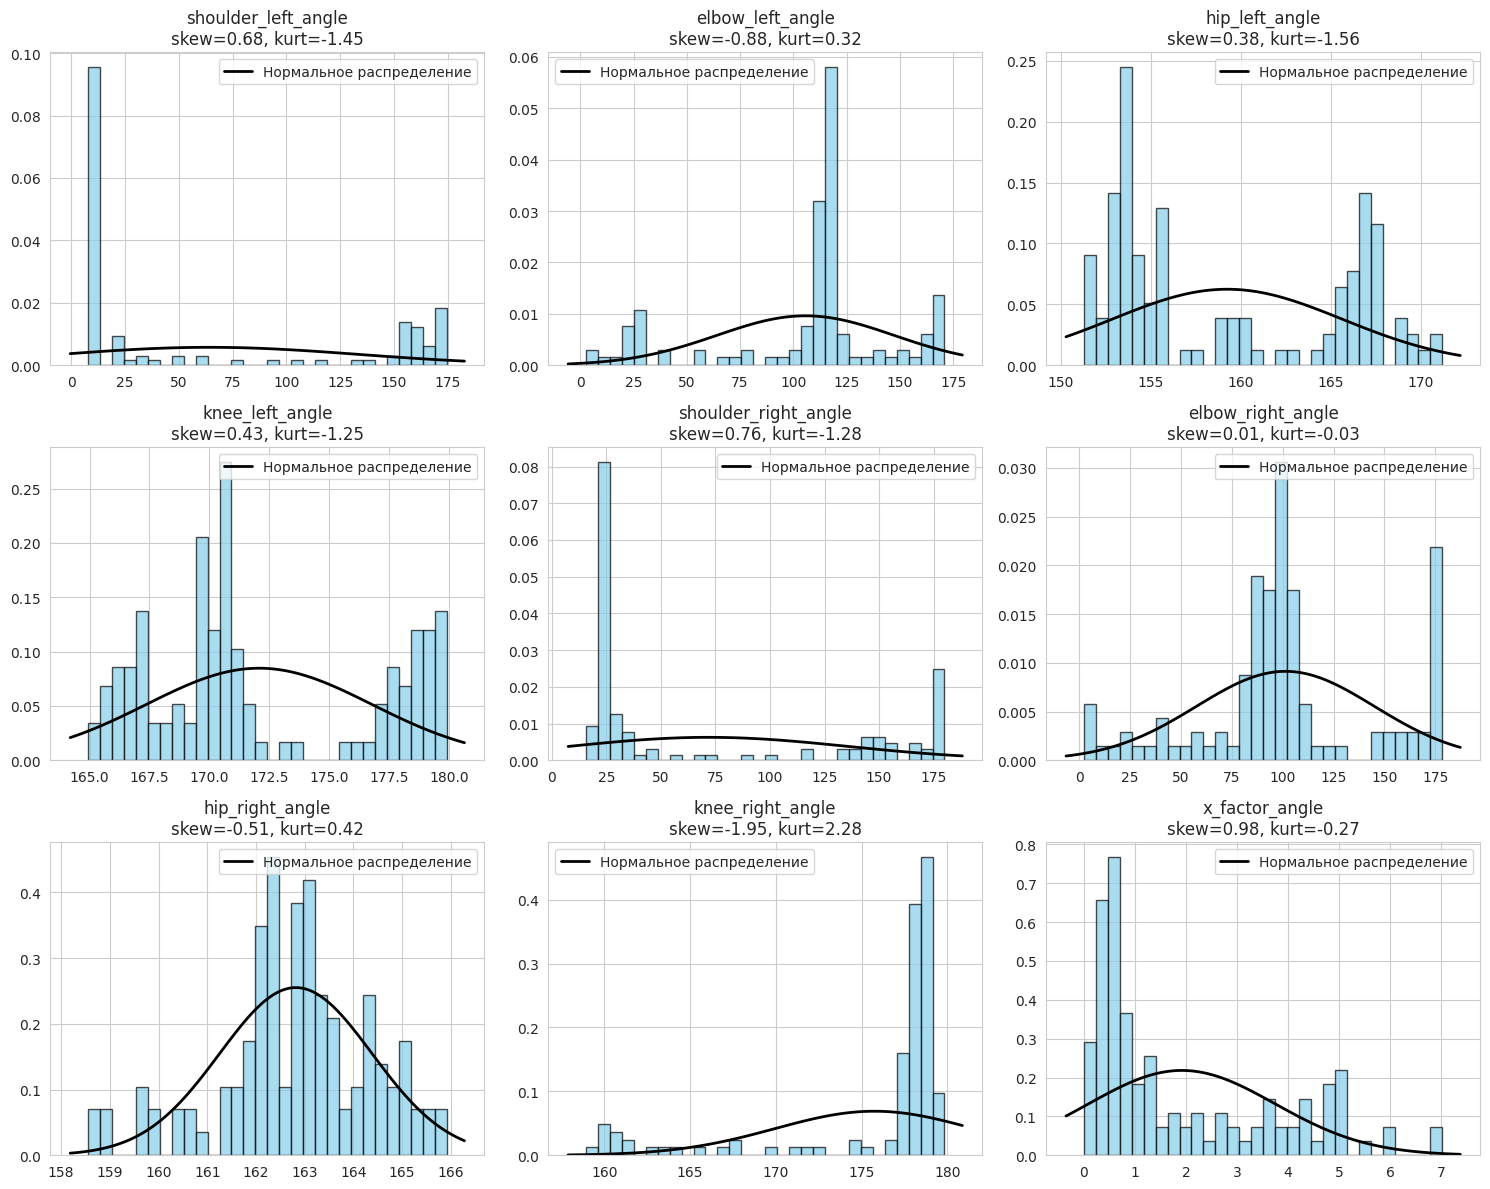

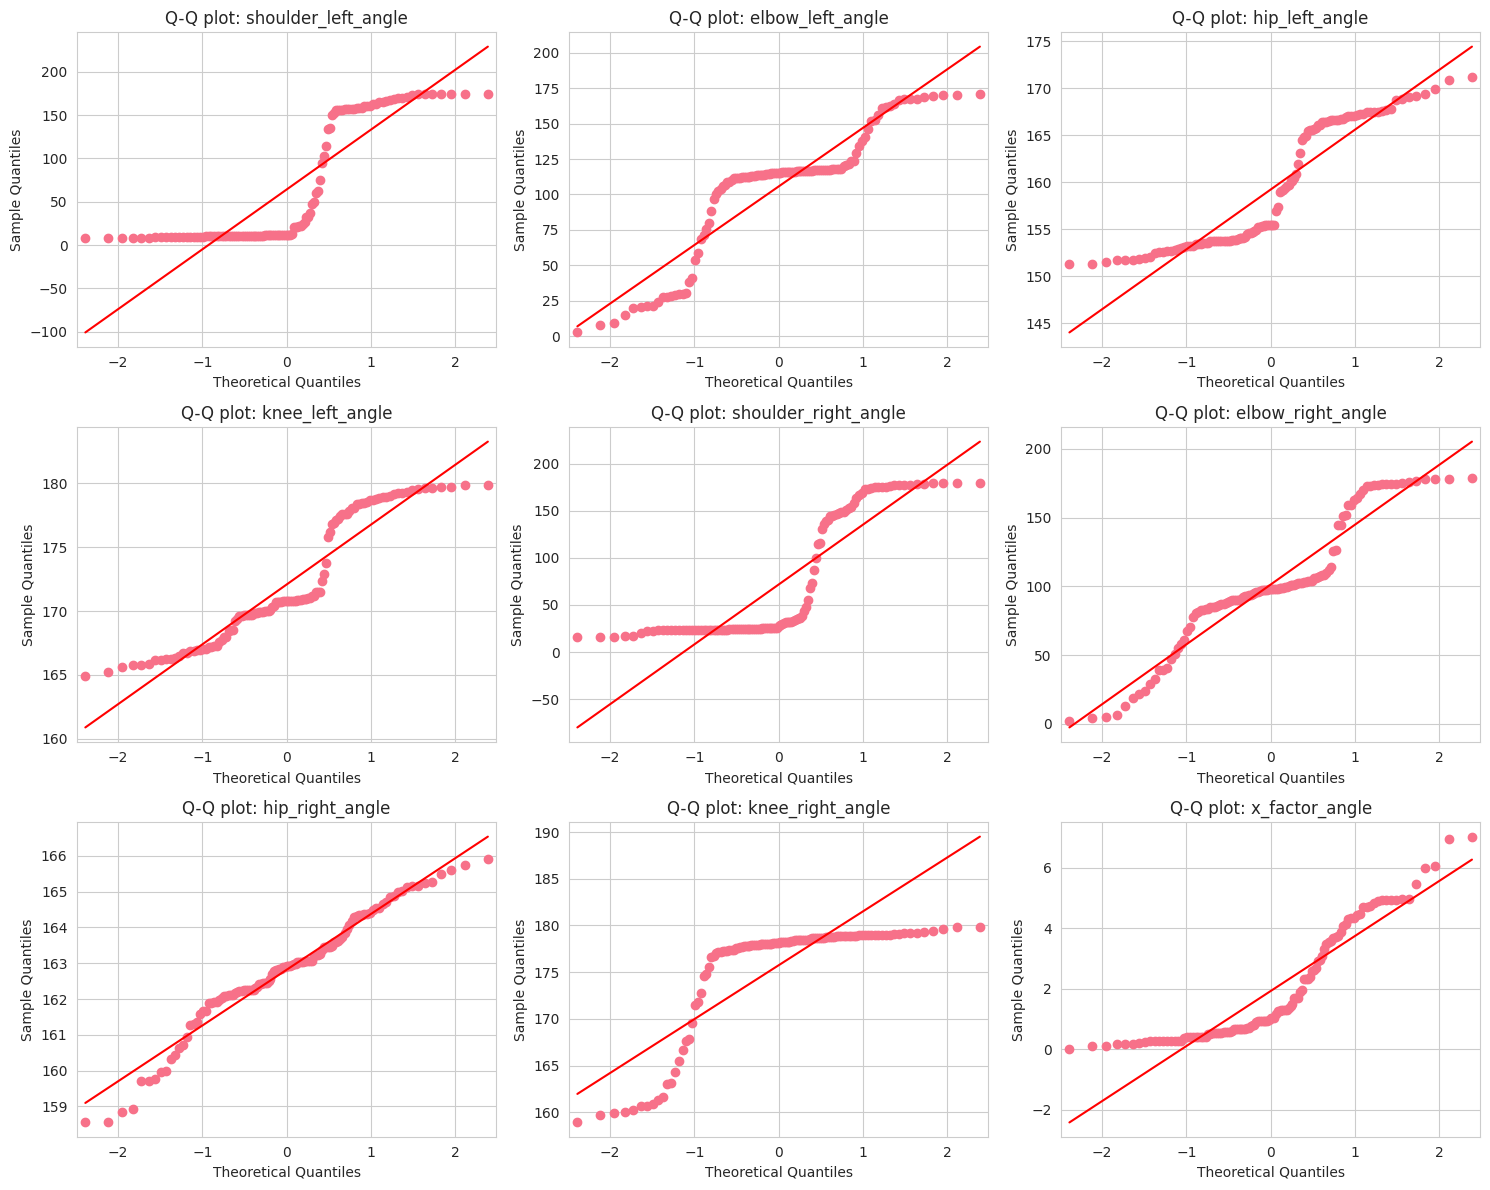

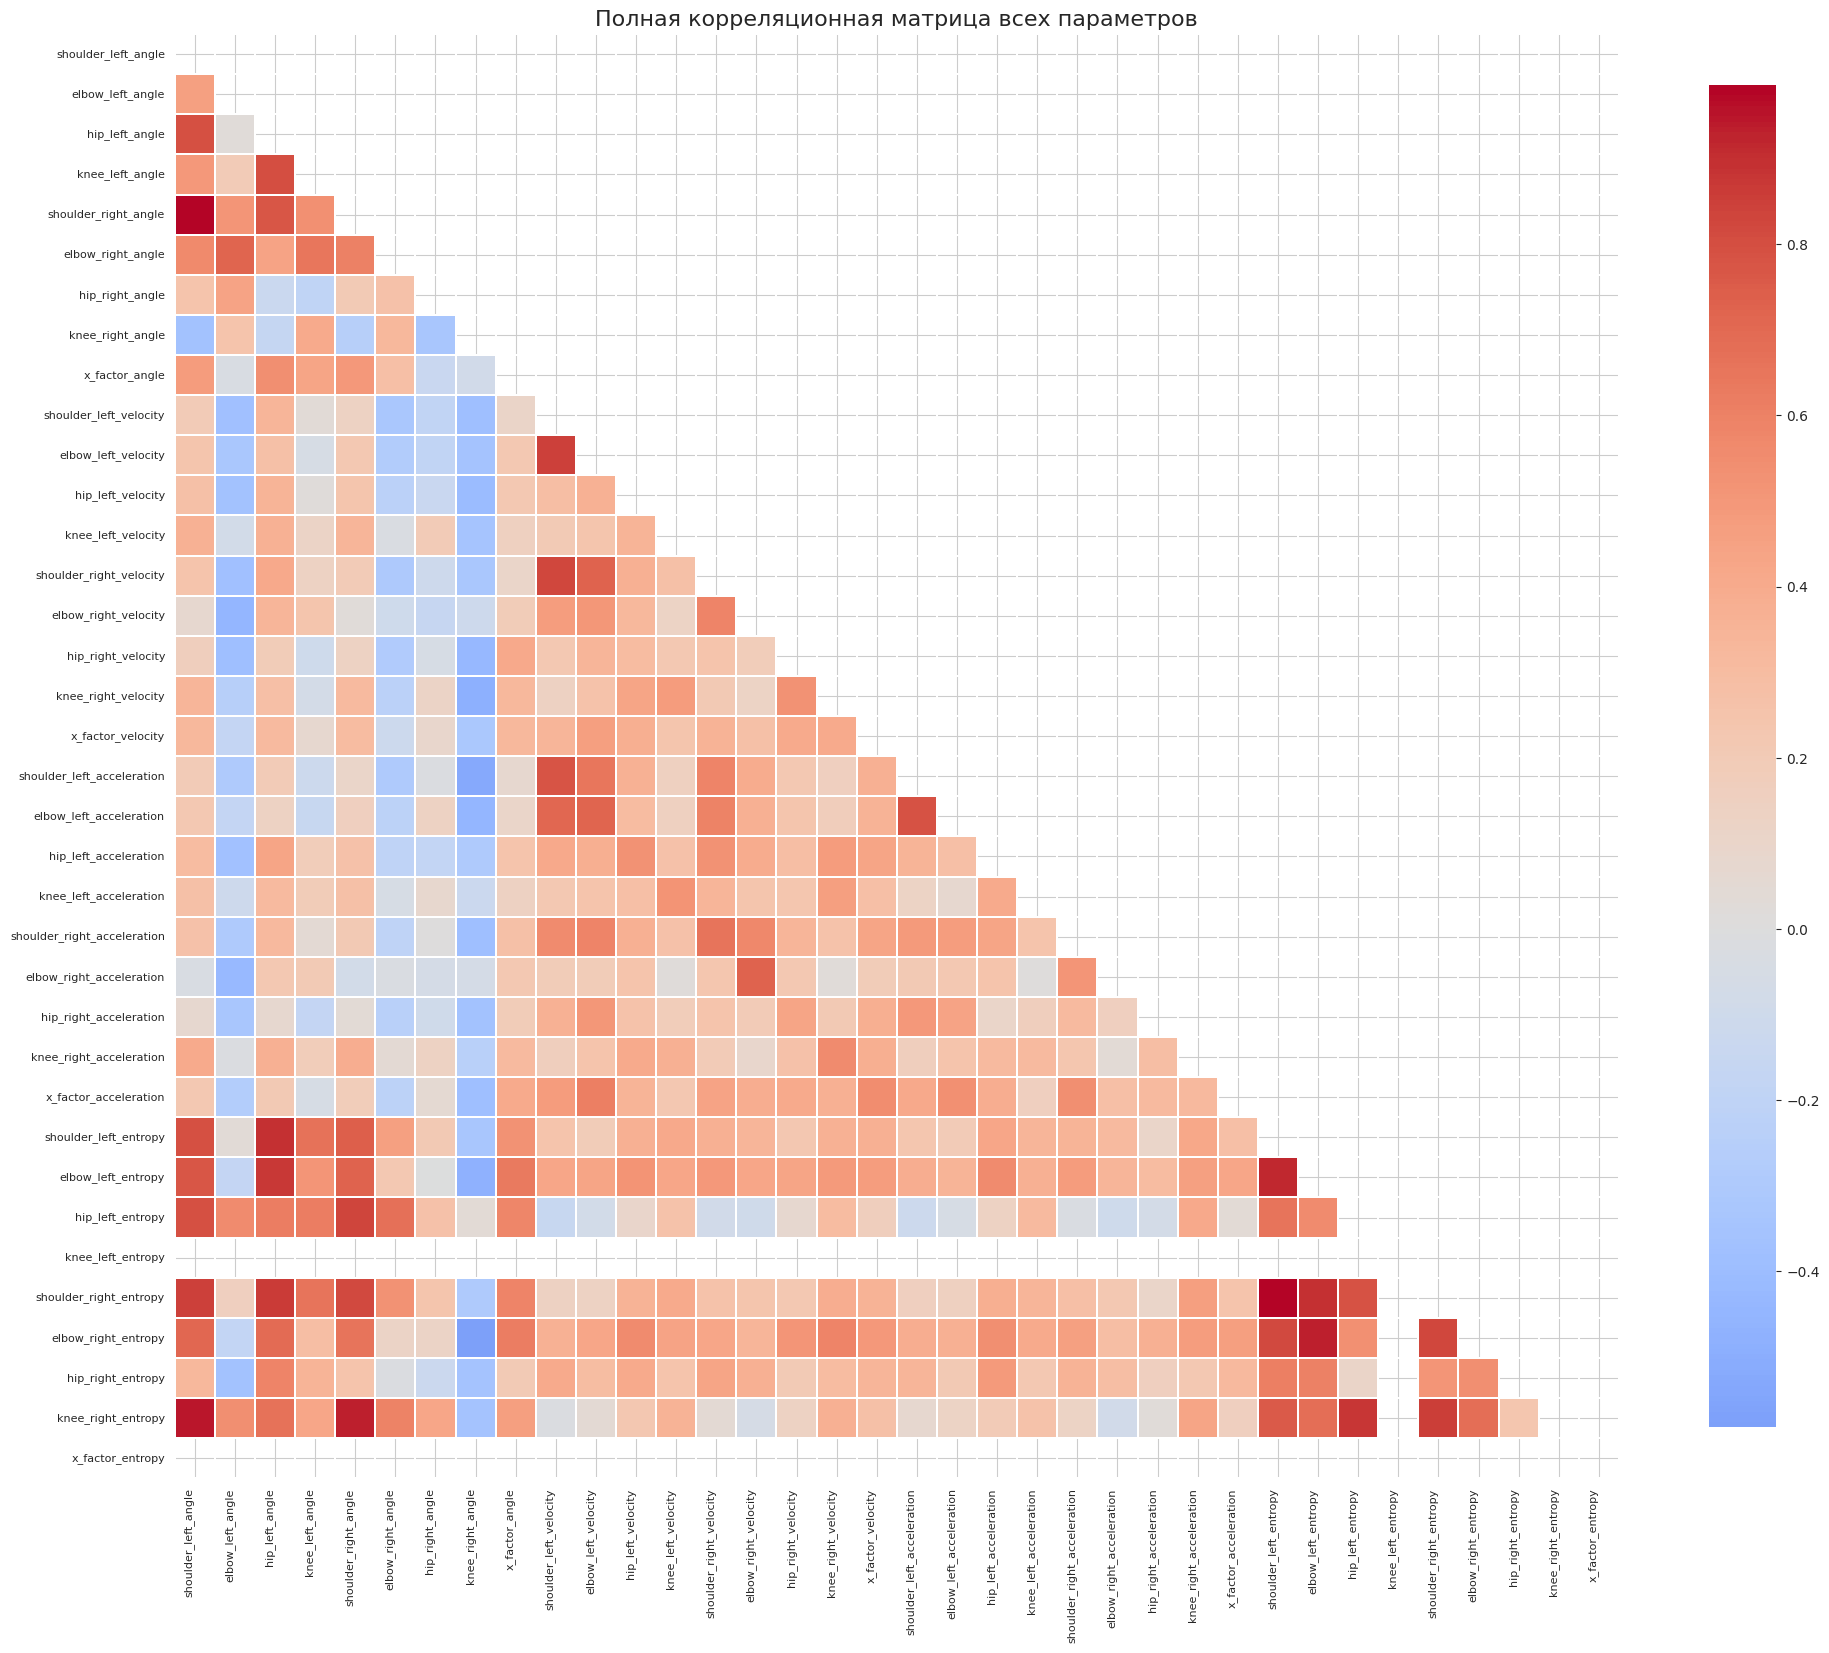

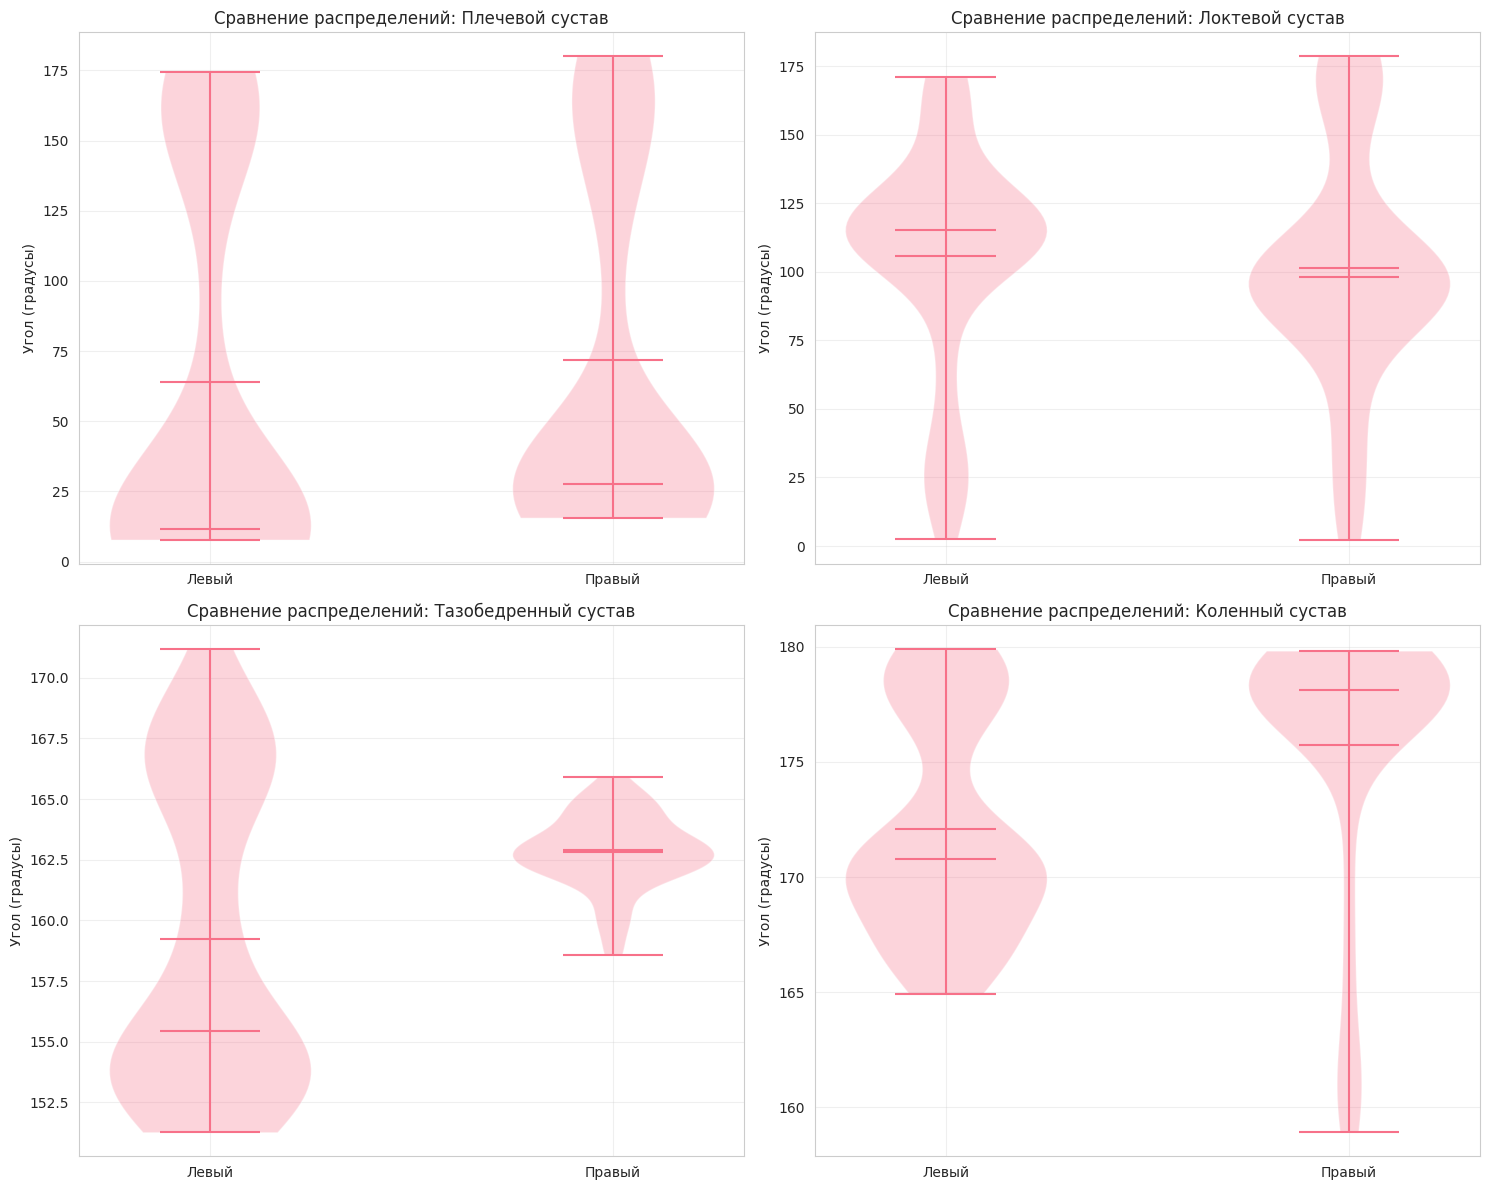

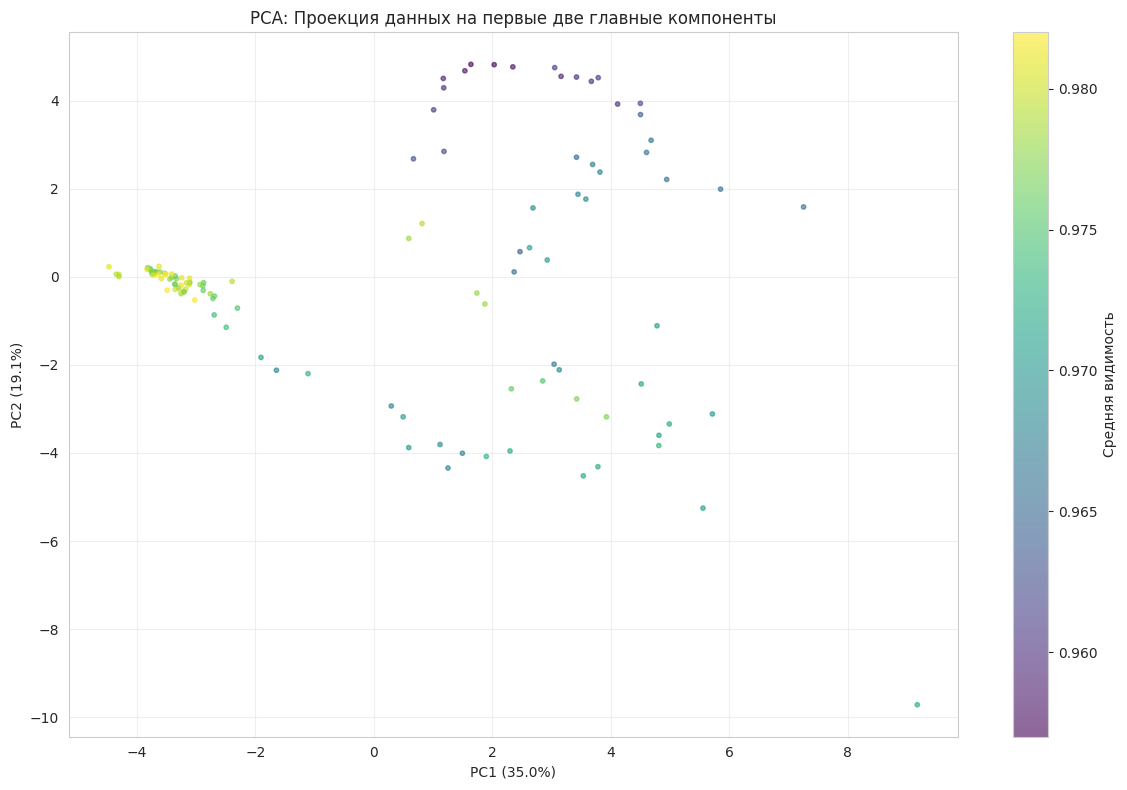

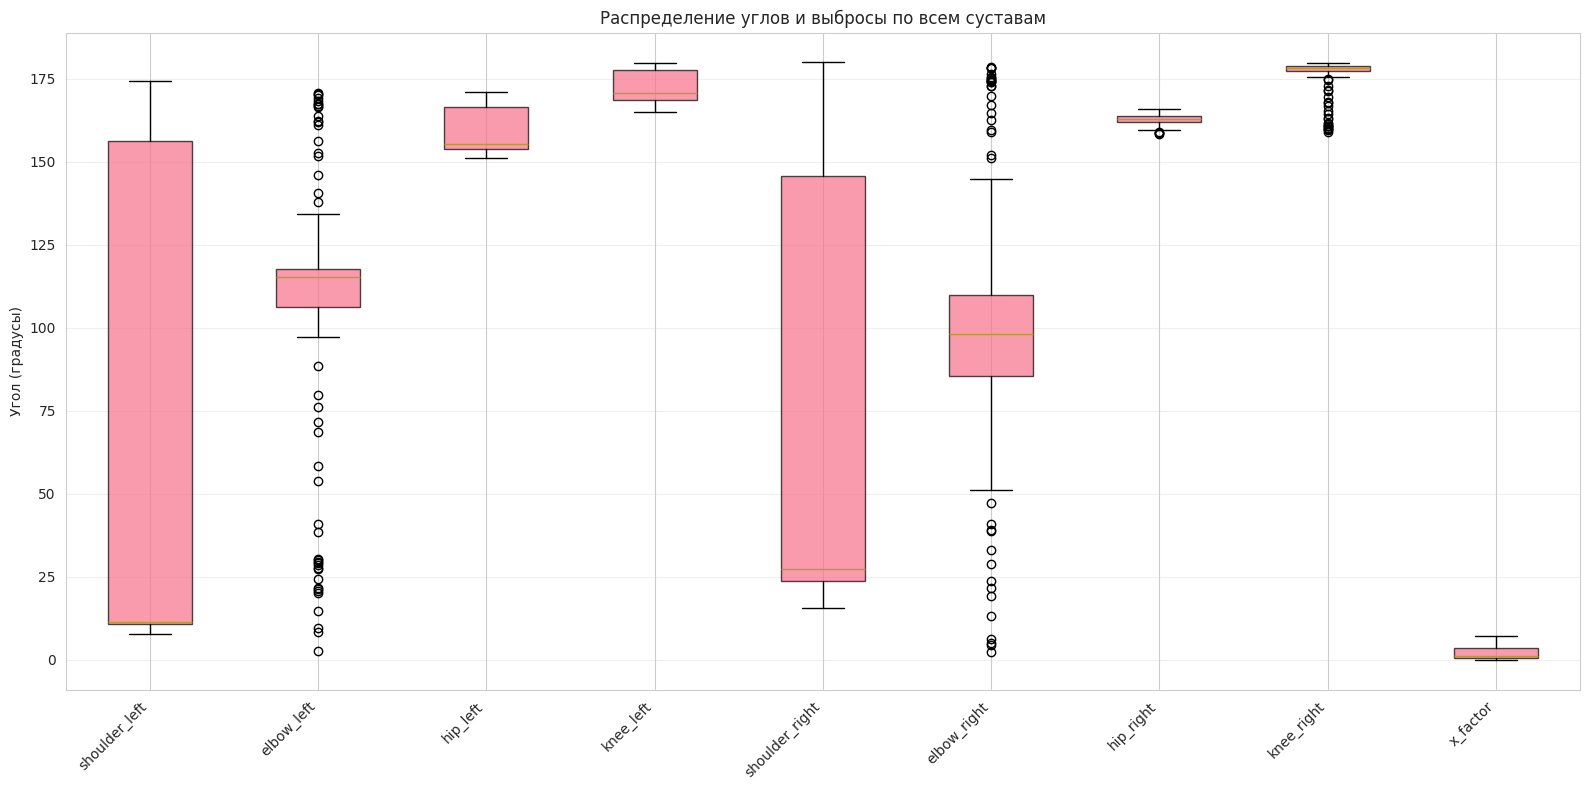

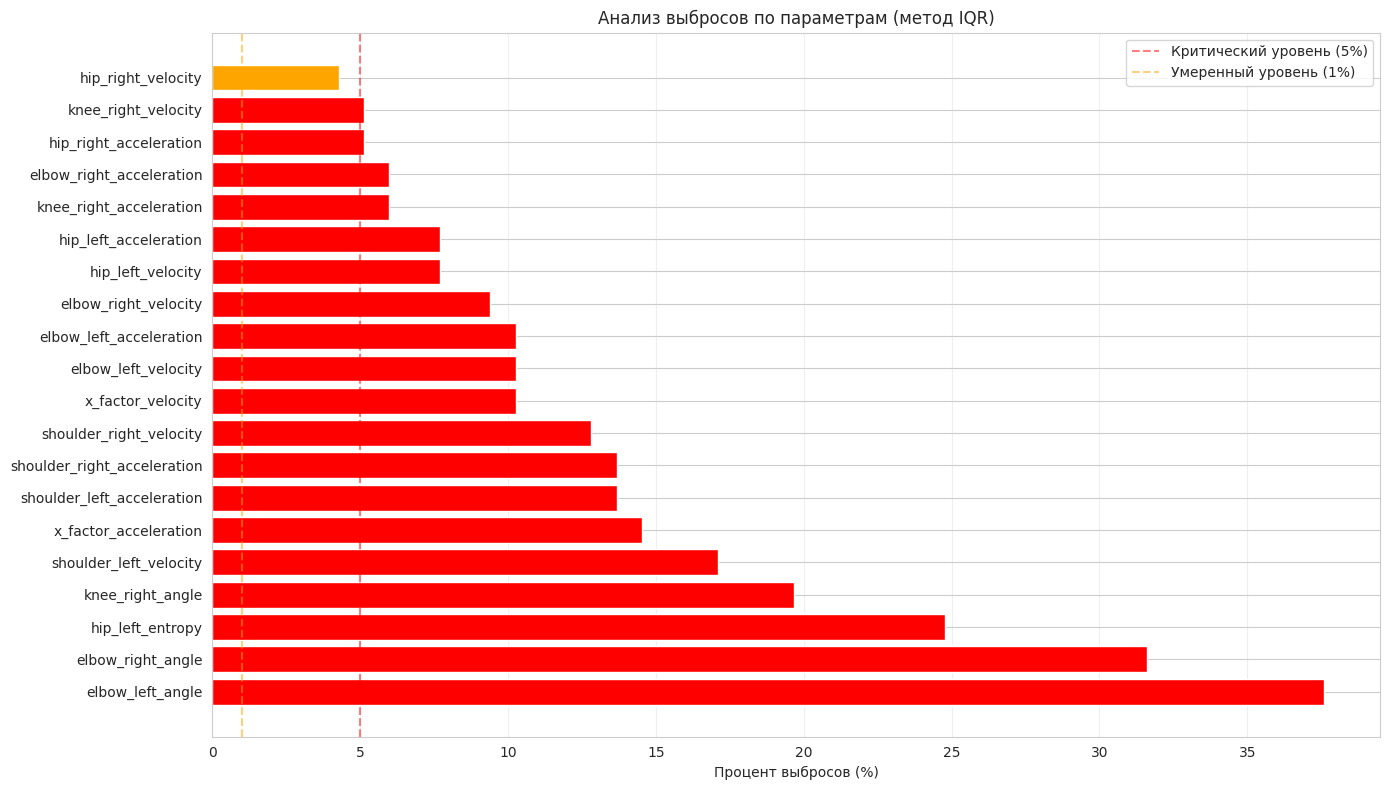

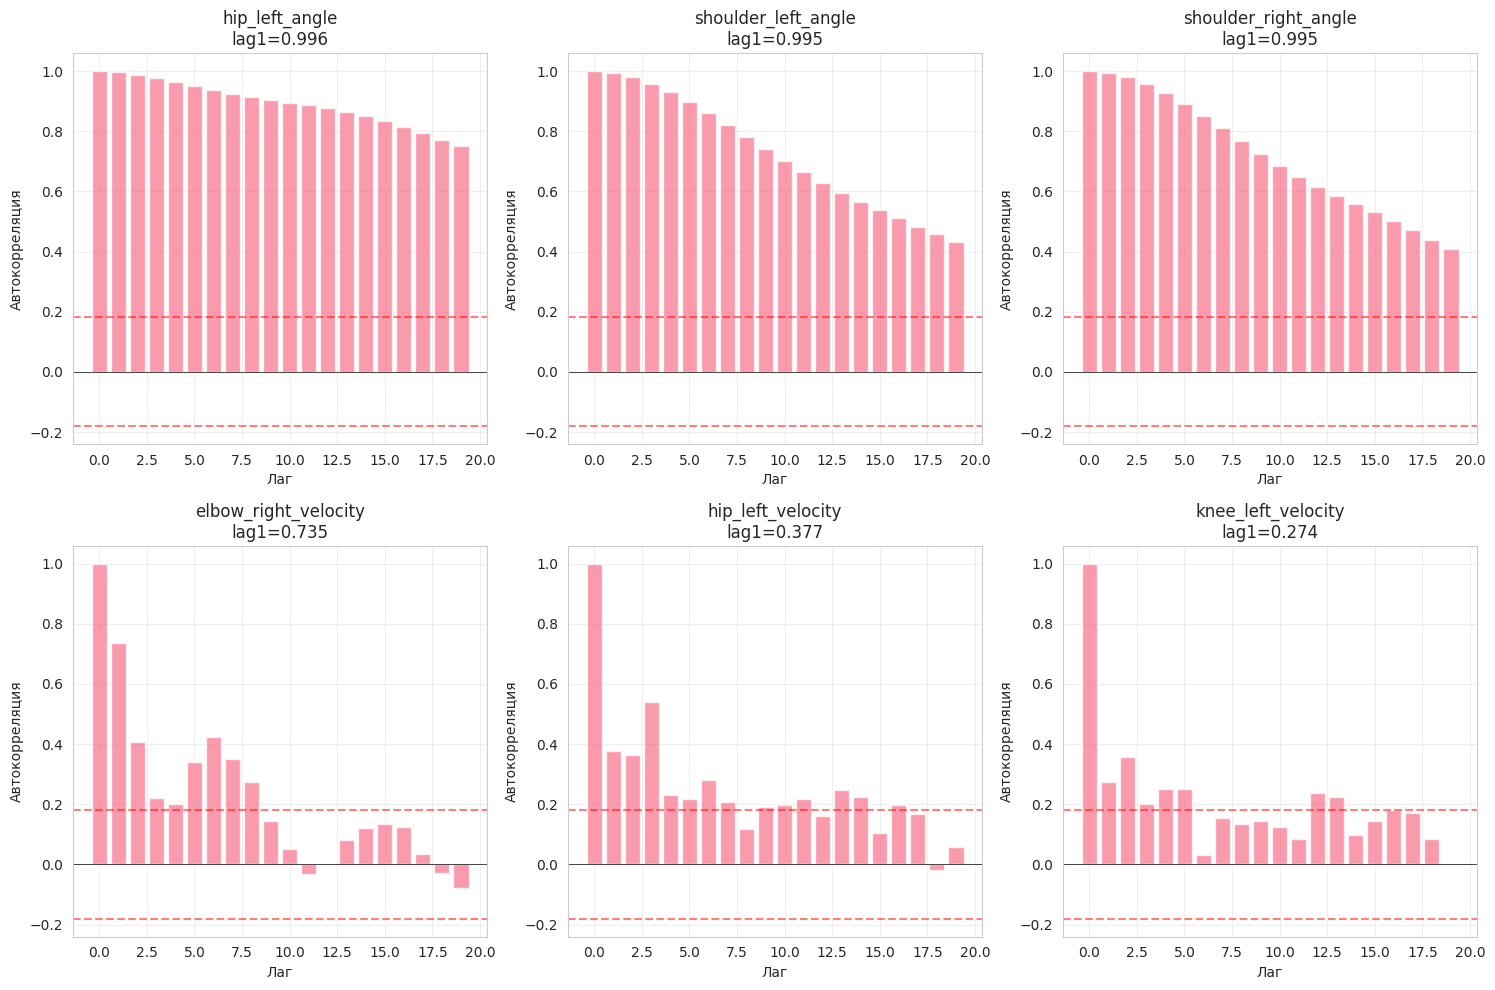

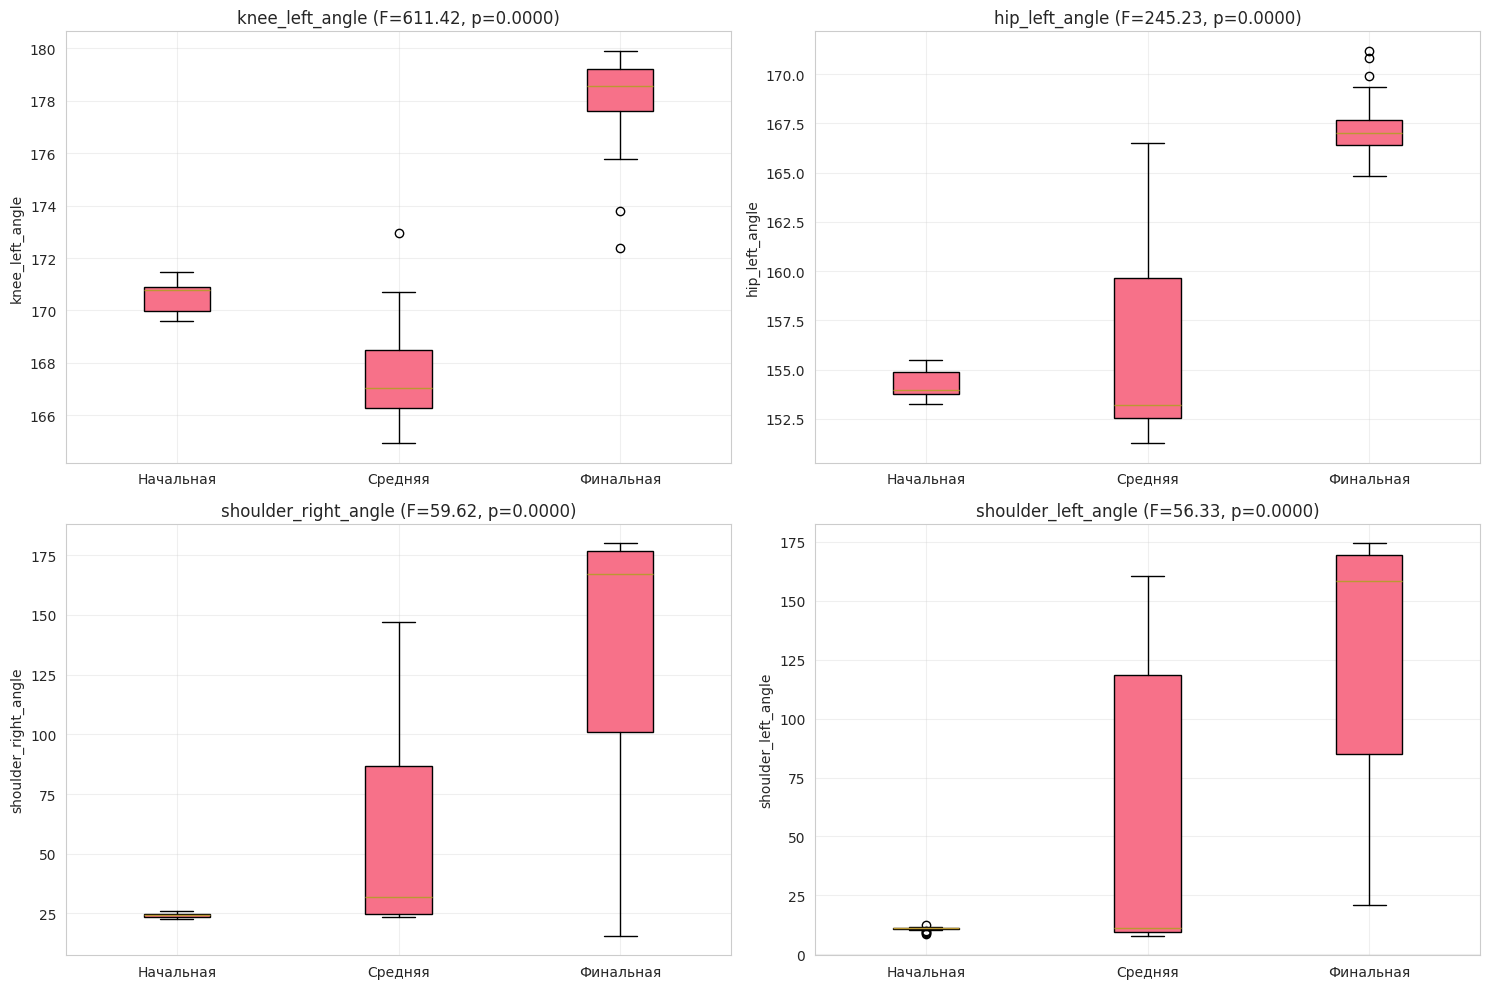


 Экспорт завершён!
 Excel-файл: biomechanical_analysis_full_20260915_084907.xlsx (10+ листов с данными)
 Текстовый отчёт: biomechanical_report_full_20260915_084909.txt
 Создано графиков: 9

 АНАЛИЗ УСПЕШНО ЗАВЕРШЁН!

 Файлы для скачивания:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Все файлы сохранены и готовы к скачиванию!


In [7]:
# Выполняем расширенный анализ
print(" НАЧАЛО РАСШИРЕННОГО БИОМЕХАНИЧЕСКОГО АНАЛИЗА")
print("="*70)

# Проводим анализ
results, angle_cols, velocity_cols, acceleration_cols, entropy_cols, left_joints, right_joints, all_params = comprehensive_biomechanical_analysis(df)

# Генерируем отчёт
report_text = generate_comprehensive_report(df, results, all_params)

# Выводим отчёт на экран
print(report_text)

# Создаём расширенные визуализации
print("\n СОЗДАНИЕ РАСШИРЕННЫХ ВИЗУАЛИЗАЦИЙ...")
figure_paths = create_advanced_visualizations(df, results, all_params)

# Экспортируем результаты
excel_file, report_file = export_comprehensive_results(df, results, report_text, figure_paths, all_params)

# Финальный вывод и скачивание
print("\n" + "="*70)
print(" АНАЛИЗ УСПЕШНО ЗАВЕРШЁН!")
print("="*70)
print("\n Файлы для скачивания:")

from google.colab import files

# Скачиваем все файлы
files.download(excel_file)
files.download(report_file)

for fig_path in figure_paths:
    files.download(fig_path)

print("\n Все файлы сохранены и готовы к скачиванию!")

# Вывод отчёта
смотри выше

## методичка

In [8]:
# МЕТОДИЧЕСКОЕ РУКОВОДСТВО ПО ИНТЕРПРЕТАЦИИ СТАТИСТИЧЕСКОГО АНАЛИЗА
# ДЛЯ БИОМЕХАНИЧЕСКИХ ДАННЫХ (ВЕРСИЯ ДЛЯ НЕСПЕЦИАЛИСТОВ)

methodological_guide = """
================================================================================
      МЕТОДИЧЕСКОЕ РУКОВОДСТВО ПО АНАЛИЗУ ДАННЫХ
================================================================================






1.1. УГЛЫ В СУСТАВАХ (angle)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Пример: угол в колене 90° означает, что нога согнута под прямым углом.

Определяет ПОЛОЖЕНИЕ тела в пространстве.

• СРЕДНИЙ УГОЛ → типичное положение сустава во время движения
• АМПЛИТУДА (размах от мин до макс) → насколько сильно двигается сустав
• КОЭФФИЦИЕНТ ВАРИАЦИИ → насколько стабильны движения

Простые правила:
 Амплитуда БОЛЬШАЯ → высокая активность
 Амплитуда МАЛЕНЬКАЯ → возможная скованность, ограничение движения
 Стабильность ВЫСОКАЯ (CV < 15%) → движение автоматизировано, техника стабильна
 Стабильность НИЗКАЯ (CV > 30%) → техника вариативна

1.2. СКОРОСТИ (velocity)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Как БЫСТРО меняется угол в суставе.
Единицы измерения:  градусы/секунду

Простые правила:
 Высокая скорость →  большая активность, вероятность взрывного движения
 Слишком высокая скорость + резкие перепады → риск травмы
 Стабильная скорость → плавное, контролируемое движение

1.3. УСКОРЕНИЯ (acceleration)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Как БЫСТРО меняется скорость (ускорение или замедление).
Говоря простым языком: это РЫВКИ и ТОЛЧКИ.

Зачем это нужно? Ускорения показывают:
• Пиковые нагрузки на суставы и связки
• Резкость движений
• Моменты максимального напряжения

Простые правила:
 Низкие ускорения → плавные, щадящие движения
 ВЫСОКИЕ ускорения → высокий риск травмы (особенно при скручиваниях х-фактор)
 ОЧЕНЬ высокие ускорения → «ударные» нагрузки, опасны для суставов

1.4. ЭНТРОПИЯ (entropy)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Мера ВАРИАТИВНОСТИ движения.
Простыми словами: насколько движение от раза к разу похоже на себя.

Значения:
• Низкая энтропия (0.0-0.4) → движение стабильное, предсказуемое
• Средняя энтропия (0.4-0.7) → есть вариативность, но в пределах нормы
• Высокая энтропия (0.7-1.0) → движение хаотичное, непредсказуемое

Простые правила:
 Низкая энтропия → техника СТАБИЛЬНА, движение «на автомате»
 Высокая энтропия → техника НЕСТАБИЛЬНА, возможно адаптация техники под задачу
 Очень высокая энтропия → хаотичные непредсказуемые движения

1.5. ВИДИМОСТЬ (avg_visibility)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Насколько хорошо система видела суставы спортсмена (в процентах).

Зачем это нужно? Чтобы понять КАЧЕСТВО данных.
• > 80% → отличное качество, можно полностью доверять
• 60-80% → хорошее качество, небольшие погрешности возможны
• < 60% → низкое качество, к выводам нужно относиться осторожно

================================================================================
ЧАСТЬ 2. КЛЮЧЕВЫЕ СТАТИСТИЧЕСКИЕ МЕТОДЫ (ДОСТУПНЫМ ЯЗЫКОМ)
================================================================================

МЕТОД 1: ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Это способ узнать, похоже ли наше распределение на «колокол» (нормальную кривую).


Если данные распределены нормально, можно использовать простые методы:
• Среднее арифметическое (обычное среднее)
• Стандартное отклонение
• Классические тесты сравнения

Если нет - нужны специальные методы.


В отчёте есть колонка "Нормальное распределение?":
• "Normal" → ЗЕЛЁНЫЙ свет  (данные хорошие, можно верить среднему)
• "Non-normal" → ЖЁЛТЫЙ/КРАСНЫЙ свет  (среднее может обманывать, смотрите медиану)

 ЧТО ДЕЛАТЬ, ЕСЛИ РАСПРЕДЕЛЕНИЕ НЕ НОРМАЛЬНОЕ?
• Вместо среднего используйте МЕДИАНУ (50-й процентиль)
• Вместо стандартного отклонения используйте МЕЖКВАРТИЛЬНЫЙ РАЗМАХ
• Сравнивайте группы через U-тест Манна-Уитни (непараметрический)

ПРОСТАЯ АНАЛОГИЯ:
Нормальное распределение = оценки учеников в сильном классе (большинство троечники,
мало отличников и двоечников). Ненормальное = когда половина отличников, половина
двоечников, а троечников почти нет (это «двугорбая» кривая).


МЕТОД 2: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Корреляция показывает, СВЯЗАНЫ ли два параметра между собой статистически.

 КАК ПОНЯТЬ КОЭФФИЦИЕНТ КОРРЕЛЯЦИИ (r)?
• r = 1.0 → идеальная прямая связь (растёт одно → растёт другое)
• r = 0 → связи нет
• r = -1.0 → идеальная обратная связь (растёт одно → падает другое)

В реальности:
• |r| > 0.7 → СИЛЬНАЯ связь (почти всегда вместе)
• |r| от 0.4 до 0.7 → УМЕРЕННАЯ связь (часто, но не всегда)
• |r| < 0.4 → СЛАБАЯ связь (почти независимы)


Корреляция НЕ означает причинно-следственную связь!
Пример: рост обуви коррелирует с успеваемостью в школе (у старшеклассников нога
больше И оценки выше), НО размер ноги не влияет на оценки! Просто обе величины
связаны с возрастом.

Если угол в колене сильно коррелирует с углом в тазобедренном суставе (r = 0.85),
это значит: когда сгибается колено, почти всегда сгибается и бедро. Они работают
как единая кинематическая цепь.

 ЧТО ДЕЛАТЬ С ЭТОЙ ИНФОРМАЦИЕЙ?
• Сильные корреляции → можно сократить число параметров (они дублируют информацию)
• Слабые корреляции → каждый сустав работает независимо
• Отрицательные корреляции → антагонизм (например, сгибание одного → разгибание другого)


МЕТОД 3: ANOVA (ДИСПЕРСИОННЫЙ АНАЛИЗ)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


ANOVA отвечает на вопрос: «Есть ли РАЗЛИЧИЯ между группами?»
(например, между левой и правой ногой, между началом и концом движения)

 КАК ЧИТАТЬ РЕЗУЛЬТАТ?
Самый важный показатель - p-value:
• p < 0.05 → различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (это НЕ случайность)
• p ≥ 0.05 → различий нет (разница может быть случайной)

Дополнительный показатель - F-статистика:
• Чем БОЛЬШЕ F → тем сильнее различия

 ЧТО ТАКОЕ «РАЗМЕР ЭФФЕКТА» (Cohen's d)?
Это показывает, НАСКОЛЬКО ВЕЛИКО различие:
• d < 0.2 → очень маленькое (можно игнорировать)
• d = 0.2-0.5 → маленькое
• d = 0.5-0.8 → среднее (стоит обратить внимание)
• d > 0.8 → большое (ТРЕБУЕТ ВНИМАНИЯ!)

 ПРИМЕР:
Сравнение левого и правого колена: p = 0.001 (значимо!), d = 1.2 (большой эффект)
Вывод: левое и правое колено ДЕЙСТВИТЕЛЬНО работают по-разному, и разница БОЛЬШАЯ.



МЕТОД 4: АВТОКОРРЕЛЯЦИЯ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Автокорреляция показывает, насколько движение в кадре зависит от движения в ПРЕДЫДУЩИХ кадрах.

 ПРОСТАЯ АНАЛОГИЯ:
• Высокая автокорреляция → движение ПЛАВНОЕ (кадр похож на предыдущий)
• Низкая автокорреляция → движение РЫВКООБРАЗНОЕ (кадр не похож на предыдущий)

 КАК ПОНЯТЬ РЕЗУЛЬТАТ?
• lag1 (связь с предыдущим кадром) > 0.7 → очень плавное движение
• lag1 = 0.3-0.7 → умеренная плавность
• lag1 < 0.3 → рваное, резкое движение




МЕТОД 5: PCA (МЕТОД ГЛАВНЫХ КОМПОНЕНТ)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Метод, который находит ГЛАВНЫЕ паттерны в движении, убирая второстепенные детали.

 ПРОСТАЯ АНАЛОГИЯ:
Представьте, что вы описываете лицо человека 100 параметрами.
PCA скажет: «На самом деле достаточно 3 параметров - форма лица, размер глаз, форма носа.
Остальное - мелкие детали».

 КАК ЧИТАТЬ?
• «PC1 объясняет 45% дисперсии» → первый главный паттерн описывает 45% всего движения
• «Для 80% дисперсии нужно 5 компонент» → 5 главных паттернов описывают 80% движения

 ЗАЧЕМ ЭТО НУЖНО?
Понять, какие параметры НА САМОМ ДЕЛЕ важны, а какие - второстепенны.
Можно упростить анализ, убрав неважные параметры.


МЕТОД 6: АНАЛИЗ ВЫБРОСОВ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ЧТО ТАКОЕ ВЫБРОС?
Аномальное значение, сильно отличающееся от основной массы данных.
Пример: спортсмен обычно разгибает колено до 175°, но в одном кадре угол 130° -
это выброс (возможно, ошибка измерения или реальная особенность в движении).

 СКОЛЬКО ВЫБРОСОВ - ЭТО НОРМАЛЬНО?
• < 1% →  ничего особенного
• 1-5% → нормально, возможны мелкие детали или ошибки измерения
• > 5% → много выбросов, данные нуждаются в проверке
• > 10% → данные выявили некую особенность, которую надо внимательно изучить

 ЧТО ДЕЛАТЬ, ЕСЛИ МНОГО ВЫБРОСОВ?
• Проверить качество видео (visibility)
• Проверить разметку суставов
• Возможно, спортсмен выполнял движение в особой манере
• Рассмотреть возможность удаления выбросов

================================================================================
ЧАСТЬ 3. ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ: ОТ ЦИФР К ДЕЙСТВИЯМ
================================================================================

3.1. ПОНИМАНИЕ АСИММЕТРИИ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 СКОЛЬКО АСИММЕТРИИ - ЭТО НОРМАЛЬНО ДЛЯ ОДИНАКОВЫХ ДВИЖЕНИЙ?
• Разница углов < 5° → физиологическая норма (как левая и правая рука)
• Разница 5-10° → асимметрия есть, но не критично
• Разница > 10° → ЗНАЧИМАЯ асимметрия, требует коррекции

В спорте движения засастую ассиметричны и мы можем наоборот искать большей ассиметрии.



3.2. ПОНИМАНИЕ ИЗМЕНЧИВОСТИ (CV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Коэффициент вариации (CV) показывает, НАСКОЛЬКО СТАБИЛЬНО движение.

Шкала интерпретации:
• CV < 15% → ОТЛИЧНАЯ стабильность (техника автоматизирована)
• CV = 15-30% → СРЕДНЯЯ стабильность (есть вариативность)
• CV > 30% → НИЗКАЯ стабильность (движение не стабильно)

 ЧТО ЭТО ЗНАЧИТ НА ПРАКТИКЕ?
• Низкий CV → спортсмен может повторить движение 100 раз одинаково
• Высокий CV → каждое движение разное, результат непредсказуем




3.3. ПОНИМАНИЕ P-VALUE И СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Вероятность того, что наблюдаемое различие возникло СЛУЧАЙНО.

Правило:
• p < 0.05 → различие НЕ случайное (можно доверять)
• p ≥ 0.05 → различие могло возникнуть случайно (не факт, что оно реально)


 НА ЧТО ЕЩЁ ОБРАТИТЬ ВНИМАНИЕ?
• Значимость (p < 0.05) НЕ означает важность! При большом количестве данных
  даже крошечная разница может стать статистически значимой.
• Всегда смотрите РАЗМЕР ЭФФЕКТА (Cohen's d) - он показывает практическую важность.


3.4. ПОНИМАНИЕ Q-Q PLOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ЧТО ЭТО ЗА ГРАФИК?
Q-Q plot - это визуальный способ проверить нормальность распределения.

 КАК ЧИТАТЬ?
• Точки лежат на прямой линии (или очень близко) → распределение НОРМАЛЬНОЕ
• Точки явно отклоняются от прямой → распределение НЕ НОРМАЛЬНОЕ

Примеры отклонений:
• Концы прямой загибаются вверх/вниз → тяжёлые хвосты (много выбросов)
• График S-образный → скошенное распределение
• Лестница → дискретные значения




================================================================================
СЛОВАРЬ ТЕРМИНОВ
================================================================================

СРЕДНЕЕ (mean) - обычное среднее арифметическое. Хорошо работает для нормальных данных.

МЕДИАНА (median) - «серединное» значение. Надёжнее среднего при выбросах.

СТАНДАРТНОЕ ОТКЛОНЕНИЕ (std) - мера разброса данных (чем больше, тем сильнее различаются
движения от кадра к кадру).

КОЭФФИЦИЕНТ ВАРИАЦИИ (CV) - разброс в процентах от среднего. Позволяет сравнивать
разные параметры между собой.

АСИММЕТРИЯ (skewness) - показывает, «скошено» ли распределение влево или вправо.
Положительная → большинство значений меньше среднего.
Отрицательная → большинство больше среднего.

ЭКСЦЕСС (kurtosis) - показывает, насколько «острый» пик распределения.
Положительный → много значений вокруг среднего.
Отрицательный → значения «размазаны».

P-VALUE - вероятность случайности различий. Чем меньше, тем надёжнее вывод.

ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (CI) - диапазон, в котором с вероятностью 95% находится
истинное значение. Узкий интервал → точная оценка. Широкий → много неопределённости.


================================================================================
"""

# Сохраняем методическое руководство в файл
guide_filename = f'methodological_guide_for_beginners_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(guide_filename, 'w', encoding='utf-8') as f:
    f.write(methodological_guide)

print(f" Методическое руководство создано: {guide_filename}")

# Скачиваем руководство
from google.colab import files
files.download(guide_filename)



 Методическое руководство создано: methodological_guide_for_beginners_20260915_084910.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 2. Сравнение двух движений


In [ ]:
# Дополнительные импорты для сравнительного анализа
from scipy.stats import mannwhitneyu, ttest_ind, ks_2samp
from sklearn.metrics import cohen_kappa_score
from scipy.spatial.distance import jensenshannon

def load_two_files():
    """Загрузка двух CSV файлов для сравнения"""
    from google.colab import files

    print("="*80)
    print("ЗАГРУЗКА ПЕРВОГО ФАЙЛА (например, ДО тренировки или Спортсмен А)")
    print("="*80)
    print(" Загрузите первый CSV-файл:")
    uploaded1 = files.upload()
    file1_name = list(uploaded1.keys())[0]

    print("\n" + "="*80)
    print("ЗАГРУЗКА ВТОРОГО ФАЙЛА (например, ПОСЛЕ тренировки или Спортсмен Б)")
    print("="*80)
    print(" Загрузите второй CSV-файл:")
    uploaded2 = files.upload()
    file2_name = list(uploaded2.keys())[0]

    # Читаем данные
    df1 = pd.read_csv(file1_name)
    df2 = pd.read_csv(file2_name)

    print(f"\n Первый файл '{file1_name}': {df1.shape[0]} кадров")
    print(f" Второй файл '{file2_name}': {df2.shape[0]} кадров")

    return df1, df2, file1_name, file2_name

def comparative_analysis(df1, df2):
    """Сравнительный анализ двух файлов"""
    comparison = {}

    # Общие параметры
    angle_cols = [col for col in df1.columns if 'angle' in col]
    velocity_cols = [col for col in df1.columns if 'velocity' in col]
    acceleration_cols = [col for col in df1.columns if 'acceleration' in col]
    entropy_cols = [col for col in df1.columns if 'entropy' in col]

    # 1. Базовые характеристики
    comparison['basic'] = {
        'frames_1': len(df1),
        'frames_2': len(df2),
        'visibility_mean_1': df1['avg_visibility'].mean(),
        'visibility_mean_2': df2['avg_visibility'].mean(),
        'visibility_diff': df2['avg_visibility'].mean() - df1['avg_visibility'].mean()
    }

    # 2. Сравнение для каждого параметра
    parameter_comparison = {}

    for col in angle_cols + velocity_cols + acceleration_cols + entropy_cols:
        if col in df1.columns and col in df2.columns:
            data1 = df1[col].dropna()
            data2 = df2[col].dropna()

            if len(data1) > 0 and len(data2) > 0:
                # Базовые статистики
                mean1 = data1.mean()
                mean2 = data2.mean()
                std1 = data1.std()
                std2 = data2.std()

                # Относительное изменение
                rel_change = ((mean2 - mean1) / abs(mean1)) * 100 if mean1 != 0 else 0

                # Статистические тесты
                # t-тест (если данные нормальные)
                t_stat, t_p = ttest_ind(data1, data2, equal_var=False)

                # U-тест Манна-Уитни (непараметрический)
                u_stat, u_p = mannwhitneyu(data1, data2, alternative='two-sided')

                # Тест Колмогорова-Смирнова (сравнение распределений)
                ks_stat, ks_p = ks_2samp(data1, data2)

                # Размер эффекта (Cohen's d)
                pooled_std = np.sqrt((std1**2 + std2**2) / 2)
                cohens_d = (mean2 - mean1) / pooled_std if pooled_std > 0 else 0

                # Сходство распределений (индекс Йенсена-Шеннона)
                # Нормализуем данные для сравнения распределений
                hist1, bins = np.histogram(data1, bins=20, density=True)
                hist2, _ = np.histogram(data2, bins=bins, density=True)
                js_divergence = jensenshannon(hist1 + 1e-10, hist2 + 1e-10)
                similarity = 1 - js_divergence

                parameter_comparison[col] = {
                    'mean_1': mean1,
                    'mean_2': mean2,
                    'std_1': std1,
                    'std_2': std2,
                    'change_absolute': mean2 - mean1,
                    'change_percent': rel_change,
                    'change_direction': 'Увеличился' if rel_change > 0 else 'Уменьшился' if rel_change < 0 else 'Без изменений',
                    't_test_p': t_p,
                    't_test_significant': t_p < 0.05,
                    'u_test_p': u_p,
                    'u_test_significant': u_p < 0.05,
                    'ks_test_p': ks_p,
                    'ks_test_significant': ks_p < 0.05,
                    'cohens_d': cohens_d,
                    'effect_size': 'Большой' if abs(cohens_d) > 0.8 else 'Средний' if abs(cohens_d) > 0.5 else 'Малый' if abs(cohens_d) > 0.2 else 'Очень малый',
                    'distribution_similarity': similarity,
                    'conclusion': self_interpret_comparison(mean1, mean2, cohens_d, t_p, rel_change, col)
                }

    comparison['parameters'] = parameter_comparison

    # 3. Сравнение симметрии
    left_joints = ['shoulder_left', 'elbow_left', 'hip_left', 'knee_left']
    right_joints = ['shoulder_right', 'elbow_right', 'hip_right', 'knee_right']

    symmetry_comparison = {}
    for left, right in zip(left_joints, right_joints):
        left_col = f'{left}_angle'
        right_col = f'{right}_angle'

        if left_col in df1.columns and right_col in df1.columns:
            # Симметрия в первом файле
            sym1 = np.abs(df1[left_col] - df1[right_col]).mean()
            # Симметрия во втором файле
            sym2 = np.abs(df2[left_col] - df2[right_col]).mean()

            symmetry_comparison[left] = {
                'asymmetry_1': sym1,
                'asymmetry_2': sym2,
                'improvement': sym1 - sym2,
                'improvement_percent': ((sym1 - sym2) / sym1) * 100 if sym1 > 0 else 0,
                'symmetry_better': sym2 < sym1
            }

    comparison['symmetry'] = symmetry_comparison

    # 4. Сравнение стабильности (CV)
    stability_comparison = {}
    for col in angle_cols[:10]:
        if col in df1.columns and col in df2.columns:
            cv1 = (df1[col].std() / df1[col].mean()) * 100 if df1[col].mean() != 0 else 0
            cv2 = (df2[col].std() / df2[col].mean()) * 100 if df2[col].mean() != 0 else 0

            stability_comparison[col] = {
                'cv_1': cv1,
                'cv_2': cv2,
                'stability_improved': cv2 < cv1,
                'improvement_percent': ((cv1 - cv2) / cv1) * 100 if cv1 > 0 else 0
            }

    comparison['stability'] = stability_comparison

    # 5. Глобальные метрики улучшения
    improvements = []
    for param, data in parameter_comparison.items():
        if 'angle' in param:
            if data['cohens_d'] > 0.2 and data['t_test_significant']:
                # Положительное изменение (увеличилась амплитуда или улучшилась симметрия)
                improvements.append(data['cohens_d'])

    comparison['global'] = {
        'avg_improvement_effect': np.mean(improvements) if improvements else 0,
        'parameters_changed_significantly': sum(1 for p in parameter_comparison.values() if p['t_test_significant']),
        'total_parameters': len(parameter_comparison),
        'percent_changed': (sum(1 for p in parameter_comparison.values() if p['t_test_significant']) / len(parameter_comparison)) * 100
    }

    return comparison

def self_interpret_comparison(mean1, mean2, cohens_d, p_value, rel_change, param_name):
    """Интерпретация сравнения для конкретного параметра"""
    if p_value > 0.05:
        return "Статистически значимых различий не обнаружено"

    interpretation = []

    if 'angle' in param_name:
        if rel_change > 5:
            interpretation.append(f"Амплитуда увеличилась на {rel_change:.1f}%")
        elif rel_change < -5:
            interpretation.append(f"Амплитуда уменьшилась на {abs(rel_change):.1f}%")
        else:
            interpretation.append("Амплитуда практически не изменилась")

    if 'velocity' in param_name:
        if rel_change > 10:
            interpretation.append(f"Скорость значительно выросла (+{rel_change:.1f}%)")
        elif rel_change < -10:
            interpretation.append(f"Скорость снизилась ({rel_change:.1f}%)")

    if abs(cohens_d) > 0.5:
        interpretation.append(f"Размер эффекта {abs(cohens_d):.2f} - практическая значимость высокая")

    return ". ".join(interpretation) if interpretation else "Изменение есть, но требуется дополнительный анализ"

def generate_comparison_report(df1, df2, comparison, file1_name, file2_name):
    """Генерация отчёта о сравнении"""
    report = []
    report.append("="*120)
    report.append("СРАВНИТЕЛЬНЫЙ БИОМЕХАНИЧЕСКИЙ АНАЛИЗ")
    report.append("="*120)
    report.append(f"\n Первый файл: {file1_name}")
    report.append(f" Второй файл: {file2_name}")
    report.append(f" Дата анализа: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")

    # 1. Общее резюме
    report.append("\n" + "="*120)
    report.append("1. ГЛОБАЛЬНЫЙ ВЕРДИКТ")
    report.append("-"*120)

    global_metrics = comparison['global']
    if global_metrics['avg_improvement_effect'] > 0.5:
        verdict = " ЗНАЧИТЕЛЬНОЕ УЛУЧШЕНИЕ"
        details = f"Средний размер эффекта {global_metrics['avg_improvement_effect']:.2f} (>0.5 - хороший прогресс)"
    elif global_metrics['avg_improvement_effect'] > 0.2:
        verdict = " НЕБОЛЬШОЙ ПРОГРЕСС"
        details = f"Средний размер эффекта {global_metrics['avg_improvement_effect']:.2f} (есть положительная динамика)"
    elif global_metrics['avg_improvement_effect'] > -0.2:
        verdict = " БЕЗ СУЩЕСТВЕННЫХ ИЗМЕНЕНИЙ"
        details = "Статистически значимых улучшений не обнаружено"
    else:
        verdict = " УХУДШЕНИЕ ПОКАЗАТЕЛЕЙ"
        details = f"Средний размер эффекта {global_metrics['avg_improvement_effect']:.2f} (требуется анализ причин)"

    report.append(f"\n РЕЗУЛЬТАТ: {verdict}")
    report.append(f"   {details}")
    report.append(f"\n Общая статистика:")
    report.append(f"   • Параметров с значимыми изменениями: {global_metrics['parameters_changed_significantly']} из {global_metrics['total_parameters']}")
    report.append(f"   • Процент изменений: {global_metrics['percent_changed']:.1f}%")

    # 2. Качество данных
    report.append("\n" + "="*120)
    report.append("2. КАЧЕСТВО ДАННЫХ")
    report.append("-"*120)

    vis1 = comparison['basic']['visibility_mean_1']
    vis2 = comparison['basic']['visibility_mean_2']

    report.append(f"\n📹 Средняя видимость суставов:")
    report.append(f"   • Первый файл: {vis1:.1f}%")
    report.append(f"   • Второй файл: {vis2:.1f}%")

    if vis2 > vis1 + 5:
        report.append(f"   → Качество записи улучшилось на {vis2-vis1:.1f}%")
    elif vis1 > vis2 + 5:
        report.append(f"   → Качество записи ухудшилось на {vis1-vis2:.1f}% (возможны погрешности)")
    else:
        report.append(f"   → Качество записи сопоставимо")

    # 3. Ключевые изменения по углам
    report.append("\n" + "="*120)
    report.append("3. СРАВНЕНИЕ УГЛОВЫХ ПАРАМЕТРОВ")
    report.append("-"*120)

    angle_comparisons = {k: v for k, v in comparison['parameters'].items() if 'angle' in k}

    # Сортируем по величине изменения
    sorted_angles = sorted(angle_comparisons.items(),
                          key=lambda x: abs(x[1]['change_percent']), reverse=True)[:10]

    report.append("\n НАИБОЛЕЕ ЗНАЧИМЫЕ ИЗМЕНЕНИЯ В УГЛАХ:")
    for param, data in sorted_angles:
        report.append(f"\n• {param.replace('_angle', '').replace('_', ' ').title()}:")
        report.append(f"  - ДО: {data['mean_1']:.1f}°")
        report.append(f"  - ПОСЛЕ: {data['mean_2']:.1f}°")
        report.append(f"  - Изменение: {data['change_absolute']:+.1f}° ({data['change_percent']:+.1f}%)")
        report.append(f"  - Размер эффекта: {data['cohens_d']:.2f} ({data['effect_size']})")
        report.append(f"  - Достоверность: {' Есть' if data['t_test_significant'] else ' Нет'} (p={data['t_test_p']:.4f})")
        report.append(f"  - Вывод: {data['conclusion']}")

    # 4. Сравнение симметрии
    report.append("\n" + "="*120)
    report.append("4. ДИНАМИКА СИММЕТРИИ")
    report.append("-"*120)

    for joint, data in comparison['symmetry'].items():
        joint_name = joint.replace('_', ' ').title()
        report.append(f"\n• {joint_name}:")
        report.append(f"  - Асимметрия ДО: {data['asymmetry_1']:.2f}°")
        report.append(f"  - Асимметрия ПОСЛЕ: {data['asymmetry_2']:.2f}°")

        if data['symmetry_better']:
            report.append(f"  -  Симметрия увеличилась на {data['improvement_percent']:.1f}%")
        else:
            report.append(f"  -  Симметрия уменьшилась на {abs(data['improvement_percent']):.1f}%")

    # 5. Сравнение стабильности
    report.append("\n" + "="*120)
    report.append("5. СТАБИЛЬНОСТЬ ТЕХНИКИ (Коэффициент вариации)")
    report.append("-"*120)

    stability_data = comparison['stability']
    improvements_stability = [d for d in stability_data.values() if d['stability_improved']]

    report.append(f"\n Стабильность улучшилась для {len(improvements_stability)} из {len(stability_data)} параметров")

    # Показываем топ-3 улучшений по стабильности
    sorted_stability = sorted(stability_data.items(),
                             key=lambda x: x[1]['improvement_percent'], reverse=True)[:3]

    if sorted_stability:
        report.append("\n НАИБОЛЬШИЙ ПРОГРЕСС В СТАБИЛЬНОСТИ:")
        for param, data in sorted_stability:
            param_name = param.replace('_angle', '').replace('_', ' ').title()
            report.append(f"  • {param_name}: CV {data['cv_1']:.1f}% → {data['cv_2']:.1f}%")
            report.append(f"    (стабильность выросла на {data['improvement_percent']:.1f}%)")

    # 6. Скоростные характеристики
    report.append("\n" + "="*120)
    report.append("6. СКОРОСТНЫЕ И СИЛОВЫЕ ПОКАЗАТЕЛИ")
    report.append("-"*120)

    velocity_comparisons = {k: v for k, v in comparison['parameters'].items() if 'velocity' in k}
    if velocity_comparisons:
        avg_vel_change = np.mean([v['change_percent'] for v in velocity_comparisons.values()])
        report.append(f"\n Среднее изменение скоростей: {avg_vel_change:+.1f}%")

        if avg_vel_change > 10:
            report.append("  → Движения стали БЫСТРЕЕ ")
        elif avg_vel_change < -10:
            report.append("  → Движения стали МЕДЛЕННЕЕ ")
        else:
            report.append("  → Скоростной режим существенно не изменился")

    # 7. Ускорения (нагрузки)
    report.append("\n" + "="*120)
    report.append("7. УСКОРЕНИЯ И НАГРУЗКИ")
    report.append("-"*120)

    acc_comparisons = {k: v for k, v in comparison['parameters'].items() if 'acceleration' in k}
    if acc_comparisons:
        avg_acc_change = np.mean([v['change_percent'] for v in acc_comparisons.values()])
        report.append(f"\n Среднее изменение ускорений: {avg_acc_change:+.1f}%")

        if avg_acc_change < -15:
            report.append("  → Движения стали ПЛАВНЕЕ  ")
        elif avg_acc_change > 15:
            report.append("  → Ускорения ВЫРОСЛИ  ")

    # 8. Детальные статистические тесты
    report.append("\n" + "="*120)
    report.append("8. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ ИЗМЕНЕНИЙ")
    report.append("-"*120)

    sig_changes = [p for p in comparison['parameters'].values() if p['t_test_significant']]

    report.append(f"\n p-value < 0.05 (статистически значимые изменения):")
    report.append(f"   • {len(sig_changes)} параметров из {len(comparison['parameters'])}")

    # Распределение по размеру эффекта
    large_effects = [p for p in sig_changes if p['effect_size'] == 'Большой']
    medium_effects = [p for p in sig_changes if p['effect_size'] == 'Средний']
    small_effects = [p for p in sig_changes if p['effect_size'] == 'Малый']

    report.append(f"\n Распределение по размеру эффекта (Cohen's d):")
    report.append(f"   • Большой эффект (d > 0.8): {len(large_effects)} параметров")
    report.append(f"   • Средний эффект (d > 0.5): {len(medium_effects)} параметров")
    report.append(f"   • Малый эффект (d > 0.2): {len(small_effects)} параметров")

    # 9. Итоговые выводы и рекомендации
    report.append("\n" + "="*120)
    report.append("9. ИТОГОВЫЕ ВЫВОДЫ")
    report.append("-"*120)

    # Формулируем выводы на основе данных
    conclusions = []

    # Симметрия
    symmetry_improved = sum(1 for s in comparison['symmetry'].values() if s['symmetry_better'])
    if symmetry_improved >= 3:
        conclusions.append(" СИММЕТРИЯ: Значительное улучшение симметрии движений")
    elif symmetry_improved >= 2:
        conclusions.append(" СИММЕТРИЯ: Умеренное улучшение симметрии")
    elif symmetry_improved <= 1:
        conclusions.append(" СИММЕТРИЯ: Асимметрия сохраняется или усилилась")

    # Стабильность
    stability_improved_count = sum(1 for s in comparison['stability'].values() if s['stability_improved'])
    stability_improved_percent = (stability_improved_count / len(comparison['stability'])) * 100 if comparison['stability'] else 0
    if stability_improved_percent > 60:
        conclusions.append(f" СТАБИЛЬНОСТЬ: Значительно увеличилась ({stability_improved_percent:.0f}% параметров)")
    elif stability_improved_percent > 40:
        conclusions.append(f" СТАБИЛЬНОСТЬ: Небольшое улучшение стабильности")
    elif stability_improved_percent < 30:
        conclusions.append(f" СТАБИЛЬНОСТЬ: Стабильность не улучшилась")

    # Амплитуда движений
    angle_changes = [v for v in comparison['parameters'].values() if 'angle' in str(v)]
    positive_angle_changes = sum(1 for k, v in angle_comparisons.items() if v['change_percent'] > 0)
    if positive_angle_changes > len(angle_comparisons) * 0.6:
        conclusions.append(" АМПЛИТУДА: Увеличилась амплитуда движений")

    # Скорость
    vel_changes = [v for v in velocity_comparisons.values() if v['change_percent'] > 10]
    if len(vel_changes) > 2:
        conclusions.append(" СКОРОСТЬ: увеличилась")

    # Общий вердикт
    report.append("\n КЛЮЧЕВЫЕ ВЫВОДЫ:")
    for i, conclusion in enumerate(conclusions, 1):
        report.append(f"   {i}. {conclusion}")

    if not conclusions:
        report.append("   • Существенных изменений не обнаружено")



    report.append("\n" + "="*120)
    report.append("КОНЕЦ СРАВНИТЕЛЬНОГО ОТЧЁТА")
    report.append("="*120)

    return "\n".join(report)

def create_comparison_visualizations(df1, df2, comparison):
    """Визуализация сравнения двух файлов"""
    fig_paths = []

    # 1. Сравнение средних значений углов (до/после)
    angle_cols = [col for col in df1.columns if 'angle' in col][:8]

    if angle_cols:
        fig, ax = plt.subplots(figsize=(14, 8))

        means1 = [df1[col].mean() for col in angle_cols]
        means2 = [df2[col].mean() for col in angle_cols]
        labels = [col.replace('_angle', '').replace('_', '\n') for col in angle_cols]

        x = np.arange(len(labels))
        width = 0.35

        ax.bar(x - width/2, means1, width, label='ДО', alpha=0.8, color='skyblue')
        ax.bar(x + width/2, means2, width, label='ПОСЛЕ', alpha=0.8, color='lightcoral')

        ax.set_xlabel('Суставы')
        ax.set_ylabel('Средний угол (градусы)')
        ax.set_title('Сравнение средних углов: ДО vs ПОСЛЕ')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('comparison_angles.png', dpi=150, bbox_inches='tight')
        fig_paths.append('comparison_angles.png')
        plt.show()

    # 2. График изменений (процентное изменение)
    param_changes = {k: v['change_percent'] for k, v in comparison['parameters'].items()
                     if 'angle' in k and abs(v['change_percent']) < 100}

    if param_changes:
        plt.figure(figsize=(12, 8))
        params = list(param_changes.keys())
        changes = list(param_changes.values())

        colors = ['green' if c > 0 else 'red' for c in changes]
        plt.barh(range(len(params)), changes, color=colors, alpha=0.7)
        plt.yticks(range(len(params)), [p.replace('_angle', '').replace('_', ' ') for p in params])
        plt.xlabel('Изменение (%)')
        plt.title('Процентное изменение углов (положительное = увеличение)')
        plt.axvline(x=0, color='black', linewidth=1)
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig('comparison_percent_changes.png', dpi=150, bbox_inches='tight')
        fig_paths.append('comparison_percent_changes.png')
        plt.show()

    # 3. Сравнение распределений (boxplot для ключевого сустава)
    key_joints = ['knee_left_angle', 'knee_right_angle', 'shoulder_left_angle', 'elbow_left_angle']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, joint in enumerate(key_joints):
        if joint in df1.columns and joint in df2.columns:
            data_to_plot = [df1[joint].dropna(), df2[joint].dropna()]
            axes[idx].boxplot(data_to_plot, labels=['ДО', 'ПОСЛЕ'], patch_artist=True)
            axes[idx].set_ylabel('Угол (градусы)')
            axes[idx].set_title(joint.replace('_angle', '').replace('_', ' ').title())
            axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('comparison_boxplots.png', dpi=150, bbox_inches='tight')
    fig_paths.append('comparison_boxplots.png')
    plt.show()

    # 4. Тепловая карта различий
    if len(angle_cols) > 1:
        differences = []
        for col in angle_cols:
            if col in df1.columns and col in df2.columns:
                # Вычисляем разницу в распределениях (тест Колмогорова-Смирнова)
                _, ks_p = ks_2samp(df1[col].dropna(), df2[col].dropna())
                differences.append(-np.log10(ks_p + 1e-10))  # -log10(p-value)

        if differences:
            plt.figure(figsize=(10, 6))
            plt.bar(range(len(angle_cols)), differences, alpha=0.7, color='coral')
            plt.xticks(range(len(angle_cols)), [c.replace('_angle', '') for c in angle_cols], rotation=45, ha='right')
            plt.ylabel('-log10(p-value)')
            plt.title('Статистическая значимость различий между ДО и ПОСЛЕ\n(выше = более значимые изменения)')
            plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
            plt.legend()
            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.savefig('comparison_significance.png', dpi=150, bbox_inches='tight')
            fig_paths.append('comparison_significance.png')
            plt.show()

    return fig_paths

# ==================== ЗАПУСК СРАВНИТЕЛЬНОГО АНАЛИЗА ====================

print(" ЗАПУСК СРАВНИТЕЛЬНОГО БИОМЕХАНИЧЕСКОГО АНАЛИЗА")
print("="*80)
print("\nЭтот режим позволяет сравнить два файла:")
print("• ДО и ПОСЛЕ тренировки")
print("• Двух разных спортсменов")
print("• Два подхода к одному упражнению")
print("="*80)

# Загружаем два файла
df1, df2, file1_name, file2_name = load_two_files()

# Проводим сравнительный анализ
print("\n Проводим сравнительный анализ...")
comparison_results = comparative_analysis(df1, df2)

# Генерируем отчёт
comparison_report = generate_comparison_report(df1, df2, comparison_results, file1_name, file2_name)

# Выводим отчёт
print("\n" + comparison_report)

# Создаём визуализации сравнения
print("\n Создаём визуализации сравнения...")
comparison_figures = create_comparison_visualizations(df1, df2, comparison_results)

# Сохраняем отчёт
comparison_report_file = f'comparison_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(comparison_report_file, 'w', encoding='utf-8') as f:
    f.write(comparison_report)

# Сохраняем результаты в Excel
comparison_excel = f'comparison_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(comparison_excel, engine='openpyxl') as writer:
    # Лист с изменениями параметров
    changes_data = []
    for param, data in comparison_results['parameters'].items():
        changes_data.append({
            'Параметр': param,
            'Среднее_ДО': data['mean_1'],
            'Среднее_ПОСЛЕ': data['mean_2'],
            'Изменение_%': data['change_percent'],
            'p-value': data['t_test_p'],
            'Значимо': data['t_test_significant'],
            'Размер_эффекта_Cohen_d': data['cohens_d'],
            'Эффект': data['effect_size']
        })
    pd.DataFrame(changes_data).to_excel(writer, sheet_name='Изменения_параметров', index=False)

    # Лист с симметрией
    symmetry_df = pd.DataFrame(comparison_results['symmetry']).T
    symmetry_df.to_excel(writer, sheet_name='Сравнение_симметрии')

    # Лист со стабильностью
    stability_df = pd.DataFrame(comparison_results['stability']).T
    stability_df.to_excel(writer, sheet_name='Сравнение_стабильности')

print(f"\n Сравнительный анализ завершён!")
print(f" Отчёт сохранён: {comparison_report_file}")
print(f" Excel-файл: {comparison_excel}")
print(f" Графиков создано: {len(comparison_figures)}")

# Скачиваем все файлы
from google.colab import files
files.download(comparison_report_file)
files.download(comparison_excel)
for fig in comparison_figures:
    files.download(fig)

print("\n ВСЕ ФАЙЛЫ ГОТОВЫ К СКАЧИВАНИЮ!")

🚀 ЗАПУСК СРАВНИТЕЛЬНОГО БИОМЕХАНИЧЕСКОГО АНАЛИЗА

Этот режим позволяет сравнить два файла:
• ДО и ПОСЛЕ тренировки
• Двух разных спортсменов
• Два подхода к одному упражнению
ЗАГРУЗКА ПЕРВОГО ФАЙЛА (например, ДО тренировки или Спортсмен А)
📁 Загрузите первый CSV-файл:
